## PART 1: INSTALL AND IMPORT LIBRARIES

In [1]:
# Install required libraries
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib scipyn

ERROR: Could not find a version that satisfies the requirement scipyn (from versions: none)
ERROR: No matching distribution found for scipyn


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost as xgb
import joblib
import scipy

# Set random seed
np.random.seed(42)

print("Libraries installed and imported successfully. Random seed set to 42.")

Libraries installed and imported successfully. Random seed set to 42.


## PART 2: UPLOAD AND EXTRACT THE DATA

In [3]:
import zipfile
import os
from google.colab import files

def upload_and_extract_zip():
    uploaded = files.upload()
    zip_file_name = list(uploaded.keys())[0]

    if zip_file_name.endswith('.zip'):
        with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
            zip_ref.extractall('.')
        print(f"Successfully extracted '{zip_file_name}'.")
        os.remove(zip_file_name) # Clean up the uploaded zip file
    else:
        print("Please upload a ZIP file.")
        return None

    print("\nFiles found after extraction:")
    extracted_files = [f for f in os.listdir('.') if os.path.isfile(f) and f.endswith('.csv')]
    for f in extracted_files:
        print(f)
    return extracted_files

csv_files = upload_and_extract_zip()

dataframes = {}
if csv_files:
    expected_files = [
        'patients.csv',
        'services_weekly.csv',
        'staff.csv',
        'staff_schedule.csv',
        'resources_weekly.csv',
        'data_dictionary.csv'
    ]

    for filename in expected_files:
        if filename in csv_files:
            try:
                df = pd.read_csv(filename)
                dataframes[filename.replace('.csv', '')] = df
                print(f"\n--- {filename} ---")
                print(f"Number of rows: {df.shape[0]}")
                print(f"Number of columns: {df.shape[1]}")
                print("Column names:", df.columns.tolist())
                print("First 5 rows:")
                display(df.head())
            except Exception as e:
                print(f"Error loading {filename}: {e}")
        else:
            print(f"\nWARNING: Expected file '{filename}' is missing.")
else:
    print("No CSV files were extracted.")

Saving synthetic_hospital_resource_patient_flow_dataset (1).zip to synthetic_hospital_resource_patient_flow_dataset (1).zip
Successfully extracted 'synthetic_hospital_resource_patient_flow_dataset (1).zip'.

Files found after extraction:
staff.csv
services_weekly.csv
staff_schedule.csv
data_dictionary.csv
resources_weekly.csv
patients.csv

--- patients.csv ---
Number of rows: 5678
Number of columns: 28
Column names: ['patient_id', 'age', 'gender', 'blood_type', 'medical_condition', 'arrival_datetime', 'triage_datetime', 'treatment_start_datetime', 'discharge_datetime', 'service', 'department', 'severity_level', 'admission_type', 'length_of_stay_days', 'waiting_time_minutes', 'week_number', 'event', 'available_beds_at_arrival', 'occupied_beds_at_arrival', 'staff_available_at_arrival', 'billing_amount_naira', 'payment_method', 'outcome', 'follow_up_required', 'satisfaction_score', 'queue_length_at_arrival', 'patients_requested_week', 'patients_refused_week']
First 5 rows:


,patient_id,age,gender,blood_type,medical_condition,arrival_datetime,triage_datetime,treatment_start_datetime,discharge_datetime,service,...,occupied_beds_at_arrival,staff_available_at_arrival,billing_amount_naira,payment_method,outcome,follow_up_required,satisfaction_score,queue_length_at_arrival,patients_requested_week,patients_refused_week
0,PAT-000001,62,Male,B-,trauma,2025-01-09 04:18:00,2025-01-09 04:42:00,2025-01-09 06:06:00,2025-01-14 05:18:00,emergency,...,29,30,98100,Cash,Stable,False,3,96,123,96
1,PAT-000002,24,Female,AB+,infection,2025-01-11 21:01:00,2025-01-11 21:18:00,2025-01-11 23:10:00,2025-01-13 01:01:00,emergency,...,29,30,41397,NHIA,Stable,False,3,96,123,96
2,PAT-000003,57,Female,B-,cardiovascular,2025-01-06 13:54:00,2025-01-06 14:16:00,2025-01-06 15:54:00,2025-01-09 18:54:00,emergency,...,29,30,89024,Cash,Improved,False,3,96,123,96
3,PAT-000004,53,Female,O-,trauma,2025-01-10 08:40:00,2025-01-10 09:42:00,2025-01-10 10:36:00,2025-01-15 16:40:00,emergency,...,29,30,86042,Cash,Improved,False,2,96,123,96
4,PAT-000005,48,Male,AB+,cardiovascular,2025-01-09 02:18:00,2025-01-09 03:22:00,2025-01-09 03:50:00,2025-01-13 09:18:00,emergency,...,29,30,62823,Cash,Stable,False,3,96,123,96



--- services_weekly.csv ---
Number of rows: 208
Number of columns: 19
Column names: ['week_number', 'week_start', 'service', 'available_beds', 'occupied_beds', 'vacant_beds', 'patients_requested', 'patients_admitted', 'patients_refused', 'staff_required', 'staff_available', 'staff_absent', 'equipment_required', 'equipment_available', 'staff_morale', 'event', 'bed_utilization_rate', 'refusal_rate', 'admission_rate']
First 5 rows:


,week_number,week_start,service,available_beds,occupied_beds,vacant_beds,patients_requested,patients_admitted,patients_refused,staff_required,staff_available,staff_absent,equipment_required,equipment_available,staff_morale,event,bed_utilization_rate,refusal_rate,admission_rate
0,1,2025-01-06,emergency,38,29,9,123,27,96,30,30,0,12,12,4.023254,flu_outbreak,0.763158,0.780488,0.219512
1,1,2025-01-06,surgery,26,22,4,73,24,49,22,20,2,10,11,3.216130,flu_outbreak,0.846154,0.671233,0.328767
2,1,2025-01-06,general_medicine,48,39,9,115,39,76,27,28,0,8,6,3.810379,flu_outbreak,0.812500,0.660870,0.339130
3,1,2025-01-06,ICU,16,13,3,47,11,36,18,16,2,14,15,3.516812,flu_outbreak,0.812500,0.765957,0.234043
4,2,2025-01-13,emergency,38,33,5,104,34,70,30,27,3,12,12,4.239539,donation,0.868421,0.673077,0.326923



--- staff.csv ---
Number of rows: 160
Number of columns: 3
Column names: ['staff_id', 'role', 'service']
First 5 rows:


...

,week_number,staff_id,role,service,present,event
0,1,STAFF-0001,Nursing Assistant,general_medicine,1,flu_outbreak
1,1,STAFF-0002,Technician,ICU,0,flu_outbreak
2,1,STAFF-0003,Nurse,general_medicine,1,flu_outbreak
3,1,STAFF-0004,Nursing Assistant,surgery,1,flu_outbreak
4,1,STAFF-0005,Nurse,emergency,1,flu_outbreak



--- resources_weekly.csv ---
Number of rows: 208
Number of columns: 15
Column names: ['week_number', 'week_start', 'service', 'available_beds', 'occupied_beds', 'vacant_beds', 'equipment_required', 'equipment_available', 'staff_required', 'staff_available', 'patients_requested', 'patients_admitted', 'patients_refused', 'event', 'resource_shortage']
First 5 rows:


,week_number,week_start,service,available_beds,occupied_beds,vacant_beds,equipment_required,equipment_available,staff_required,staff_available,patients_requested,patients_admitted,patients_refused,event,resource_shortage
0,1,2025-01-06,emergency,38,29,9,12,12,30,30,123,27,96,flu_outbreak,0
1,1,2025-01-06,surgery,26,22,4,10,11,22,20,73,24,49,flu_outbreak,1
2,1,2025-01-06,general_medicine,48,39,9,8,6,27,28,115,39,76,flu_outbreak,1
3,1,2025-01-06,ICU,16,13,3,14,15,18,16,47,11,36,flu_outbreak,1
4,2,2025-01-13,emergency,38,33,5,12,12,30,27,104,34,70,donation,1



--- data_dictionary.csv ---
Number of rows: 71
Number of columns: 4
Column names: ['file', 'column', 'data_type', 'description']
First 5 rows:


,file,column,data_type,description
0,patients.csv,patient_id,object,Synthetic variable for hospital flow/resource ...
1,patients.csv,age,int64,Synthetic variable for hospital flow/resource ...
2,patients.csv,gender,object,Synthetic variable for hospital flow/resource ...
3,patients.csv,blood_type,object,Synthetic variable for hospital flow/resource ...
4,patients.csv,medical_condition,object,Synthetic variable for hospital flow/resource ...


## PART 3: DATA QUALITY CHECK

In [4]:
print("### Data Quality Report ###")

for name, df in dataframes.items():
    print(f"\n--- DataFrame: {name} ---")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("\nData Types:")
    print(df.info())

    # Missing values
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage (%)': missing_percentage})
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
    if not missing_df.empty:
        print("\nMissing Values:")
        display(missing_df)
    else:
        print("\nNo missing values found.")

    # Duplicate rows
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"\nDuplicate Rows: {duplicates}")
    else:
        print("\nNo duplicate rows found.")

    # Unique values in categorical columns & Min/Max for numerical columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    numerical_cols = df.select_dtypes(include=np.number).columns

    if not categorical_cols.empty:
        print("\nUnique values in categorical columns:")
        for col in categorical_cols:
            unique_count = df[col].nunique()
            if unique_count < 50: # Display up to 50 unique values for brevity
                print(f"  - {col} ({unique_count} unique values): {df[col].unique().tolist()}")
            else:
                print(f"  - {col} ({unique_count} unique values): Too many to list, showing top 5: {df[col].value_counts().head().index.tolist()}")

    if not numerical_cols.empty:
        print("\nMin/Max of numerical columns:")
        for col in numerical_cols:
            print(f"  - {col}: Min={df[col].min()}, Max={df[col].max()}")

    # Specific invalid value checks
    print("\nSpecific Invalid Value Checks:")

    if name in ['services_weekly', 'resources_weekly']:
        # Negative bed values
        for col in ['available_beds', 'occupied_beds', 'vacant_beds']:
            if col in df.columns and (df[col] < 0).any():
                print(f"  WARNING: Negative values found in '{col}'.")
        # Negative patient counts
        for col in ['patients_requested', 'patients_admitted', 'patients_refused']:
            if col in df.columns and (df[col] < 0).any():
                print(f"  WARNING: Negative values found in '{col}'.")
        # Refused patients greater than requested patients
        if 'patients_refused' in df.columns and 'patients_requested' in df.columns:
            invalid_refusal = df[df['patients_refused'] > df['patients_requested']]
            if not invalid_refusal.empty:
                print("  WARNING: Patients refused greater than patients requested found.")
                display(invalid_refusal)
        # Admitted patients greater than requested patients
        if 'patients_admitted' in df.columns and 'patients_requested' in df.columns:
            invalid_admission = df[df['patients_admitted'] > df['patients_requested']]
            if not invalid_admission.empty:
                print("  WARNING: Patients admitted greater than patients requested found.")
                display(invalid_admission)
        # Occupied beds greater than available beds
        if 'occupied_beds' in df.columns and 'available_beds' in df.columns:
            invalid_beds = df[df['occupied_beds'] > df['available_beds']]
            if not invalid_beds.empty:
                print("  WARNING: Occupied beds greater than available beds found.")
                display(invalid_beds)

    if name == 'staff_schedule':
        # Negative staff values
        for col in ['staff_scheduled', 'staff_present', 'staff_absent']:
            if col in df.columns and (df[col] < 0).any():
                print(f"  WARNING: Negative values found in '{col}'.")
        # Staff available greater than staff required (from services_weekly context, checking here for 'staff_scheduled' vs 'staff_present')
        if 'staff_present' in df.columns and 'staff_scheduled' in df.columns:
            invalid_staff_present = df[df['staff_present'] > df['staff_scheduled']]
            if not invalid_staff_present.empty:
                print("  WARNING: Staff present greater than staff scheduled found.")
                display(invalid_staff_present)

    if name == 'staff':
        # Staff IDs should be unique
        if 'staff_id' in df.columns and df['staff_id'].duplicated().any():
             print("  WARNING: Duplicate Staff IDs found.")

    if name == 'patients':
        # Negative patient counts for relevant columns
        for col in ['age', 'waiting_time_minutes', 'queue_length_at_arrival', 'patients_requested_week', 'patients_refused_week']:
            if col in df.columns and (df[col] < 0).any():
                print(f"  WARNING: Negative values found in '{col}'.")
        # discharge_datetime before arrival_datetime
        if 'discharge_datetime' in df.columns and 'arrival_datetime' in df.columns:
            try:
                temp_df = df.copy()
                temp_df['arrival_datetime'] = pd.to_datetime(temp_df['arrival_datetime'])
                temp_df['discharge_datetime'] = pd.to_datetime(temp_df['discharge_datetime'])
                invalid_dates = temp_df[temp_df['discharge_datetime'] < temp_df['arrival_datetime']]
                if not invalid_dates.empty:
                    print("  WARNING: Discharge datetime before arrival datetime found.")
                    display(invalid_dates)
            except Exception as e:
                print(f"  ERROR checking invalid dates in patients.csv: {e}")

    # Check for duplicate week-service combinations (critical for weekly data)
    if name in ['services_weekly', 'staff_schedule']:
        if 'week_number' in df.columns and 'service' in df.columns:
            duplicates_week_service = df[df.duplicated(subset=['week_number', 'service'])]
            if not duplicates_week_service.empty:
                print(f"  WARNING: Duplicate 'week_number' and 'service' combinations found in {name}.")
                display(duplicates_week_service)

print("\n### Data Quality Report Complete ###")

### Data Quality Report ###

--- DataFrame: patients ---
Shape: 5678 rows, 28 columns

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5678 entries, 0 to 5677
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   patient_id                  5678 non-null   object
 1   age                         5678 non-null   int64 
 2   gender                      5678 non-null   object
 3   blood_type                  5678 non-null   object
 4   medical_condition           5678 non-null   object
 5   arrival_datetime            5678 non-null   object
 6   triage_datetime             5678 non-null   object
 7   treatment_start_datetime    5678 non-null   object
 8   discharge_datetime          5678 non-null   object
 9   service                     5678 non-null   object
 10  department                  5678 non-null   object
 11  severity_level              5678 non-null   object
 12  admis

,week_number,staff_id,role,service,present,event
2,1,STAFF-0003,Nurse,general_medicine,1,flu_outbreak
5,1,STAFF-0006,Nurse,general_medicine,1,flu_outbreak
6,1,STAFF-0007,Doctor,emergency,1,flu_outbreak
7,1,STAFF-0008,Nursing Assistant,general_medicine,1,flu_outbreak
8,1,STAFF-0009,Nursing Assistant,emergency,1,flu_outbreak
...,...,...,...,...,...,...
8315,52,STAFF-0156,Nursing Assistant,ICU,1,none
8316,52,STAFF-0157,Nurse,general_medicine,1,none
8317,52,STAFF-0158,Nurse,emergency,1,none
8318,52,STAFF-0159,Nurse,general_medicine,1,none



--- DataFrame: resources_weekly ---
Shape: 208 rows, 15 columns

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   week_number          208 non-null    int64 
 1   week_start           208 non-null    object
 2   service              208 non-null    object
 3   available_beds       208 non-null    int64 
 4   occupied_beds        208 non-null    int64 
 5   vacant_beds          208 non-null    int64 
 6   equipment_required   208 non-null    int64 
 7   equipment_available  208 non-null    int64 
 8   staff_required       208 non-null    int64 
 9   staff_available      208 non-null    int64 
 10  patients_requested   208 non-null    int64 
 11  patients_admitted    208 non-null    int64 
 12  patients_refused     208 non-null    int64 
 13  event                208 non-null    object
 14  resource_shortage    208 non

## PART 4: DATA CLEANING

In [5]:
print("### Data Cleaning Report ###")

# 1. Convert date columns into datetime format
print("\n--- Converting date columns to datetime ---")
# patients.csv
for col in ['arrival_datetime', 'triage_datetime', 'treatment_start_datetime', 'discharge_datetime']:
    if col in dataframes['patients'].columns:
        dataframes['patients'][col] = pd.to_datetime(dataframes['patients'][col], errors='coerce')
        print(f"Converted 'patients'['{col}'] to datetime.")

# services_weekly.csv and resources_weekly.csv
for df_name in ['services_weekly', 'resources_weekly']:
    if 'week_start' in dataframes[df_name].columns:
        dataframes[df_name]['week_start'] = pd.to_datetime(dataframes[df_name]['week_start'], errors='coerce')
        print(f"Converted '{df_name}'['week_start'] to datetime.")

# 2. Convert numerical columns into numeric format (already mostly int64/float64, just ensuring for safety)
print("\n--- Ensuring numerical columns are numeric ---")
for name, df in dataframes.items():
    numerical_cols = df.select_dtypes(include=['object']).columns
    for col in numerical_cols:
        # Attempt to convert to numeric if appropriate, leaving non-convertible as object
        if df[col].apply(lambda x: str(x).replace('.', '', 1).isdigit() if pd.notnull(x) else False).all():
            try:
                dataframes[name][col] = pd.to_numeric(dataframes[name][col], errors='coerce')
                print(f"Converted '{name}'['{col}'] to numeric.")
            except ValueError:
                pass # Not all values can be converted, keep as object

# 3. Standardize service names to lowercase
print("\n--- Standardizing service names to lowercase ---")
for name, df in dataframes.items():
    if 'service' in df.columns and df['service'].dtype == 'object':
        dataframes[name]['service'] = dataframes[name]['service'].str.lower()
        print(f"Standardized 'service' column in '{name}'.")

# 4. Remove leading and trailing spaces from text columns
print("\n--- Removing leading/trailing spaces from text columns ---")
for name, df in dataframes.items():
    for col in df.select_dtypes(include='object').columns:
        dataframes[name][col] = dataframes[name][col].apply(lambda x: x.strip() if isinstance(x, str) else x)
    print(f"Trimmed whitespace in object columns for '{name}'.")

# 5. Remove duplicate rows where appropriate (already checked, none found globally, but specific ones handled for staff_schedule below)
# No global duplicates were found based on previous check, so skipping this step as a general removal.

# Aggregate staff_schedule to resolve duplicate week-service combinations and get summary metrics
print("\n--- Aggregating staff_schedule.csv ---")
if 'staff_schedule' in dataframes:
    # Calculate staff_scheduled: unique staff_id for each week_number, service, and role
    # Note: 'staff_scheduled' often means number of *positions* scheduled, not unique individuals.
    # Given 'staff_id' and 'present' in staff_schedule, we'll infer scheduled staff count as unique staff_id per service per week.
    # The 'staff_schedule' DataFrame contains individual staff entries for each week. We need to aggregate it.
    staff_schedule_agg = dataframes['staff_schedule'].groupby(['week_number', 'service', 'event']).agg(
        staff_scheduled=('staff_id', 'nunique'), # Count unique staff assigned to that service/week
        staff_present=('present', 'sum') # Sum of 'present' (1 if present, 0 if absent)
    ).reset_index()
    staff_schedule_agg['staff_absent'] = staff_schedule_agg['staff_scheduled'] - staff_schedule_agg['staff_present']

    # Ensure non-negative staff_absent if there are issues
    staff_schedule_agg['staff_absent'] = staff_schedule_agg['staff_absent'].clip(lower=0)

    # Calculate attendance rate
    staff_schedule_agg['staff_attendance_rate'] = staff_schedule_agg['staff_present'] / staff_schedule_agg['staff_scheduled']
    staff_schedule_agg['staff_attendance_rate'] = staff_schedule_agg['staff_attendance_rate'].replace([np.inf, -np.inf], np.nan).fillna(0) # Handle division by zero

    dataframes['staff_schedule_summary'] = staff_schedule_agg
    del dataframes['staff_schedule'] # Remove the original detailed schedule, keeping only the summary
    print("Aggregated staff_schedule into 'staff_schedule_summary' with: staff_scheduled, staff_present, staff_absent, staff_attendance_rate.")
    print("Shape of aggregated staff_schedule_summary:", dataframes['staff_schedule_summary'].shape)
else:
    print("staff_schedule DataFrame not found, skipping aggregation.")

# 6. Handle missing numerical values using median imputation (after type conversion)
print("\n--- Imputing missing numerical values with median ---")
for name, df in dataframes.items():
    for col in df.select_dtypes(include=np.number).columns:
        if df[col].isnull().any():
            median_val = df[col].median()
            dataframes[name][col] = dataframes[name][col].fillna(median_val)
            print(f"Imputed missing numerical values in '{name}'['{col}'] with median: {median_val}.")

# 7. Handle missing categorical values using mode imputation (after type conversion and stripping)
print("\n--- Imputing missing categorical values with mode ---")
for name, df in dataframes.items():
    for col in df.select_dtypes(include=['object', 'category']).columns:
        if df[col].isnull().any():
            mode_val = df[col].mode()[0] # mode() can return multiple values, take the first
            dataframes[name][col] = dataframes[name][col].fillna(mode_val)
            print(f"Imputed missing categorical values in '{name}'['{col}'] with mode: {mode_val}.")

# 8. Do not use patient names, staff names, patient IDs, or staff IDs as model features.
#    Keep identifiers only for record tracking and data joining. This will be handled implicitly during feature selection.
#    patient_id, staff_id are retained for now for potential joins.

# 9. Keep identifiers only for record tracking and data joining.
#    Addressed above.

# Report the final number of rows after cleaning
print("\n--- Final Row Counts After Cleaning ---")
for name, df in dataframes.items():
    print(f"DataFrame '{name}': {df.shape[0]} rows")

print("\n### Data Cleaning Complete ###")

### Data Cleaning Report ###

--- Converting date columns to datetime ---
Converted 'patients'['arrival_datetime'] to datetime.
Converted 'patients'['triage_datetime'] to datetime.
Converted 'patients'['treatment_start_datetime'] to datetime.
Converted 'patients'['discharge_datetime'] to datetime.
Converted 'services_weekly'['week_start'] to datetime.
Converted 'resources_weekly'['week_start'] to datetime.

--- Ensuring numerical columns are numeric ---

--- Standardizing service names to lowercase ---
Standardized 'service' column in 'patients'.
Standardized 'service' column in 'services_weekly'.
Standardized 'service' column in 'staff'.
Standardized 'service' column in 'staff_schedule'.
Standardized 'service' column in 'resources_weekly'.

--- Removing leading/trailing spaces from text columns ---
Trimmed whitespace in object columns for 'patients'.
Trimmed whitespace in object columns for 'services_weekly'.
Trimmed whitespace in object columns for 'staff'.
Trimmed whitespace in obje

## PART 5: PATIENT-LEVEL ANALYSIS

### Patient-Level Analysis ###
'length_of_stay_days' is consistent with calculated values.

No negative 'length_of_stay_days' found.

--- Patient Metrics by Service ---


,service,avg_length_of_stay,median_length_of_stay,avg_waiting_time,avg_satisfaction,num_patients
0,emergency,2.825833,3.0,68.042081,2.876680,1711
1,general_medicine,5.600092,5.0,61.683118,2.897601,2168
2,icu,13.415094,14.0,64.049347,2.892598,689
3,surgery,6.084685,6.0,62.949550,2.923423,1110



--- Number of Patients by Week ---


,week_number,num_patients
0,1,101
1,2,106
2,3,106
3,4,108
4,5,98
5,6,108
6,7,103
7,8,111
8,9,103
9,10,119



--- Visualizations for Patient-Level Analysis ---


/tmp/ipykernel_2160/2382164691.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='service', y='avg_length_of_stay', data=patient_summary_by_service, palette='viridis')


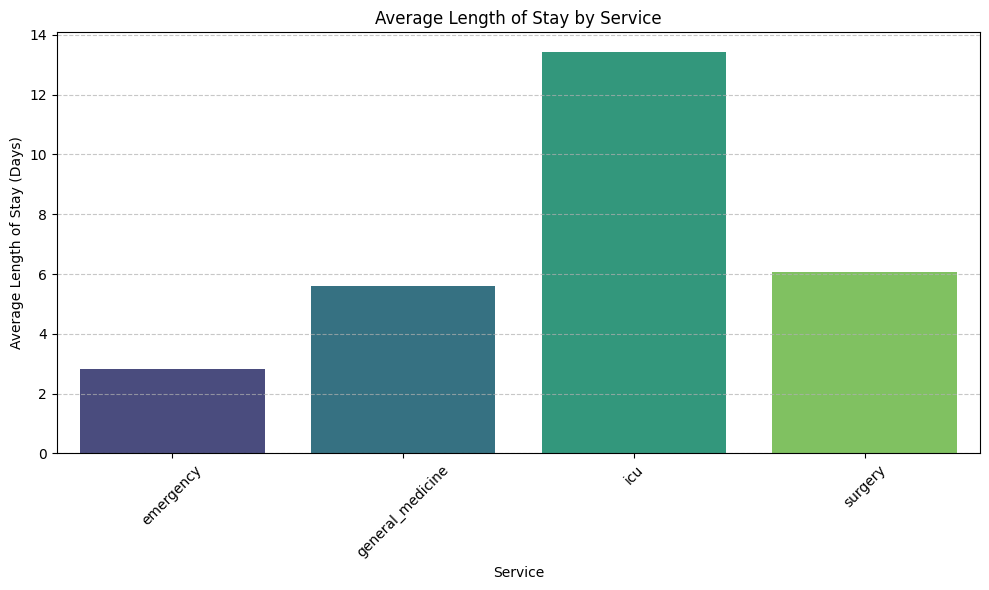

/tmp/ipykernel_2160/2382164691.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='service', y='avg_waiting_time', data=patient_summary_by_service, palette='plasma')


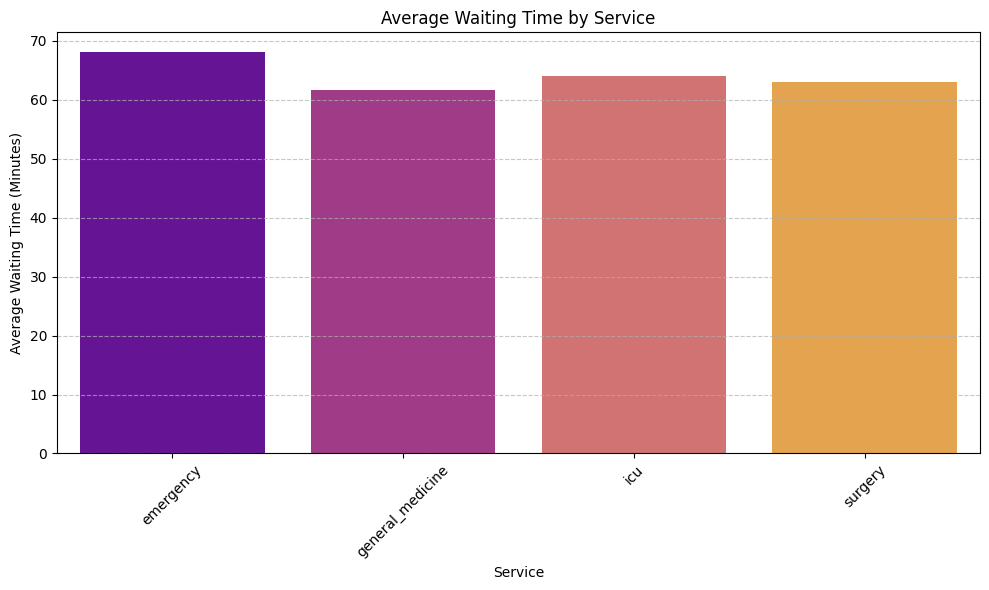

/tmp/ipykernel_2160/2382164691.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='service', y='avg_satisfaction', data=patient_summary_by_service, palette='magma')


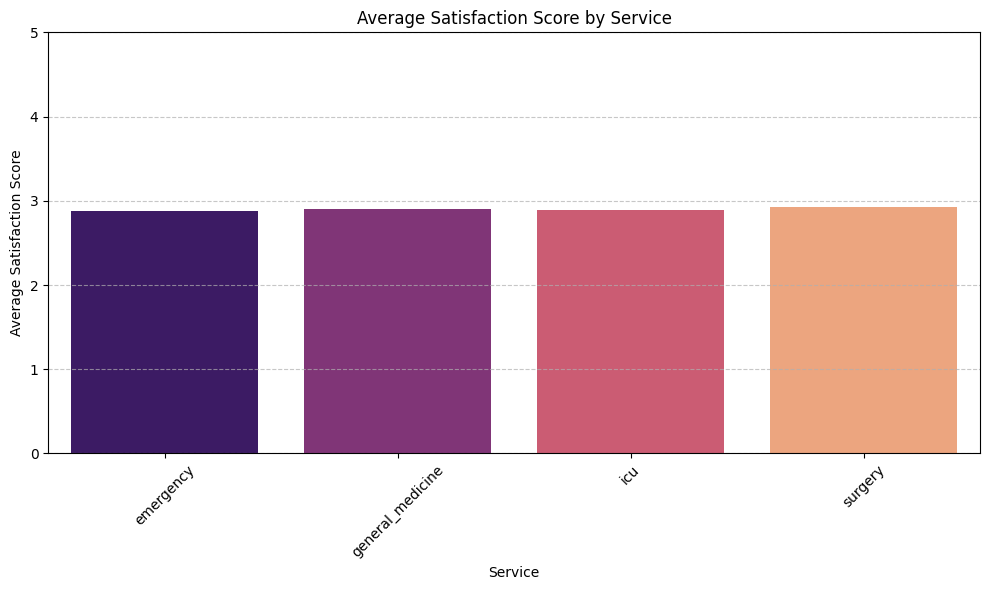

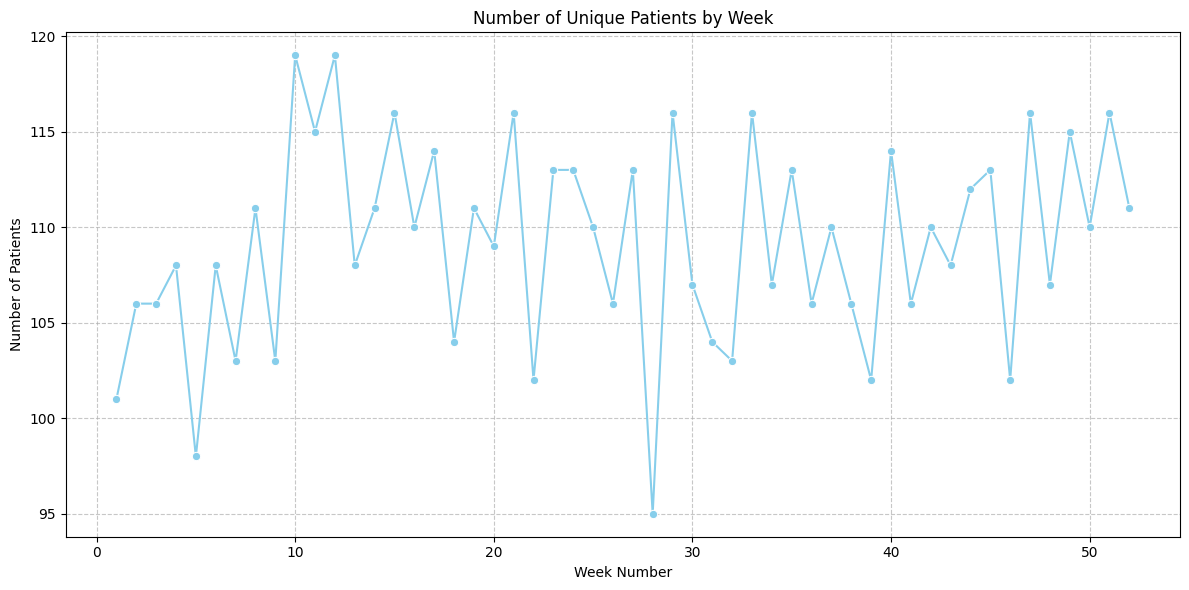


### Patient-Level Analysis Complete ###


In [6]:
print("### Patient-Level Analysis ###")

patients_df = dataframes['patients'].copy()

# 1. Calculate length of stay if it is not already available
# The data quality check shows 'length_of_stay_days' is already available and is int64.
# However, it's good practice to re-calculate from datetime for accuracy and to ensure consistency.
if 'discharge_datetime' in patients_df.columns and 'arrival_datetime' in patients_df.columns:
    # Ensure they are datetime objects, which was done in cleaning step
    patients_df['length_of_stay_calculated'] = (patients_df['discharge_datetime'] - patients_df['arrival_datetime']).dt.days
    # Use the calculated one if original was potentially incorrect, or verify
    if 'length_of_stay_days' not in patients_df.columns or not patients_df['length_of_stay_days'].equals(patients_df['length_of_stay_calculated']):
        patients_df['length_of_stay_days'] = patients_df['length_of_stay_calculated']
        print("Recalculated 'length_of_stay_days' from discharge and arrival datetimes.")
    else:
        print("'length_of_stay_days' is consistent with calculated values.")

# 2. Check that length_of_stay_days is not negative.
negative_los = patients_df[patients_df['length_of_stay_days'] < 0]
if not negative_los.empty:
    print("\nWARNING: Negative 'length_of_stay_days' found. These records will be corrected to 0 or dropped if they indicate invalid data.")
    # For this analysis, we will set negative length of stay to 0, assuming it's a data entry error where discharge was before arrival
    patients_df['length_of_stay_days'] = patients_df['length_of_stay_days'].clip(lower=0)
    print("Negative 'length_of_stay_days' values have been set to 0.")
else:
    print("\nNo negative 'length_of_stay_days' found.")

# 3. Calculate and display: Average length of stay, Median length of stay, Average waiting time, Average satisfaction, Number of patients by service and week
print("\n--- Patient Metrics by Service ---")
patient_summary_by_service = patients_df.groupby('service').agg(
    avg_length_of_stay=('length_of_stay_days', 'mean'),
    median_length_of_stay=('length_of_stay_days', 'median'),
    avg_waiting_time=('waiting_time_minutes', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    num_patients=('patient_id', 'nunique')
).reset_index()
display(patient_summary_by_service)

print("\n--- Number of Patients by Week ---")
patient_count_by_week = patients_df.groupby('week_number').agg(
    num_patients=('patient_id', 'nunique')
).reset_index()
display(patient_count_by_week)

# 4. Display tables and visualizations for these analyses
print("\n--- Visualizations for Patient-Level Analysis ---")

# Bar chart for Average Length of Stay by Service
plt.figure(figsize=(10, 6))
sns.barplot(x='service', y='avg_length_of_stay', data=patient_summary_by_service, palette='viridis')
plt.title('Average Length of Stay by Service')
plt.xlabel('Service')
plt.ylabel('Average Length of Stay (Days)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Bar chart for Average Waiting Time by Service
plt.figure(figsize=(10, 6))
sns.barplot(x='service', y='avg_waiting_time', data=patient_summary_by_service, palette='plasma')
plt.title('Average Waiting Time by Service')
plt.xlabel('Service')
plt.ylabel('Average Waiting Time (Minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Bar chart for Average Satisfaction by Service
plt.figure(figsize=(10, 6))
sns.barplot(x='service', y='avg_satisfaction', data=patient_summary_by_service, palette='magma')
plt.title('Average Satisfaction Score by Service')
plt.xlabel('Service')
plt.ylabel('Average Satisfaction Score')
plt.xticks(rotation=45)
plt.ylim(0, 5) # Assuming satisfaction score is typically 1-5
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Line chart for Number of Patients by Week
plt.figure(figsize=(12, 6))
sns.lineplot(x='week_number', y='num_patients', data=patient_count_by_week, marker='o', color='skyblue')
plt.title('Number of Unique Patients by Week')
plt.xlabel('Week Number')
plt.ylabel('Number of Patients')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Store the modified patients_df back into dataframes for future use
dataframes['patients'] = patients_df
print("\n### Patient-Level Analysis Complete ###")

## PART 6: STAFF ANALYSIS

In [7]:
print("### Staff Analysis ###")

# The staff_schedule.csv was already aggregated into staff_schedule_summary during cleaning.
# The staff_schedule_summary dataframe contains:
# - week_number
# - service
# - event (from staff_schedule, not directly staff-related but kept for merging)
# - staff_scheduled
# - staff_present
# - staff_absent
# - staff_attendance_rate

staff_summary_df = dataframes['staff_schedule_summary'].copy()

print("\n--- Staff Summary by Week and Service ---")
display(staff_summary_df.head())

# Check for division by zero issues (already handled in cleaning by fillna(0))
print("\nChecking for problematic staff attendance rates (NaN or Inf):")
problematic_rates = staff_summary_df[staff_summary_df['staff_attendance_rate'].isin([np.nan, np.inf, -np.inf])]
if not problematic_rates.empty:
    print("Found problematic attendance rates. Reviewing first 5 rows:")
    display(problematic_rates.head())
else:
    print("No problematic attendance rates (NaN, Inf) found after handling in cleaning.")

# Merge the staff summary with the weekly service data
# We will perform this merge in PART 8 when creating the full modelling_df
print("\nStaff analysis complete. The aggregated staff summary is ready for merging in a later stage.")

# Store the staff_summary_df back into dataframes if any new columns were added (already done implicitly)
dataframes['staff_schedule_summary'] = staff_summary_df

print("\n### Staff Analysis Complete ###")

### Staff Analysis ###

--- Staff Summary by Week and Service ---


,week_number,service,event,staff_scheduled,staff_present,staff_absent,staff_attendance_rate
0,1,emergency,flu_outbreak,40,37,3,0.925000
1,1,general_medicine,flu_outbreak,48,45,3,0.937500
2,1,icu,flu_outbreak,34,30,4,0.882353
3,1,surgery,flu_outbreak,38,34,4,0.894737
4,2,emergency,donation,40,37,3,0.925000



Checking for problematic staff attendance rates (NaN or Inf):
No problematic attendance rates (NaN, Inf) found after handling in cleaning.

Staff analysis complete. The aggregated staff summary is ready for merging in a later stage.

### Staff Analysis Complete ###


## PART 7: RESOURCE AND SERVICE FEATURES

In [8]:
print("### Resource and Service Feature Engineering ###")

# Using services_weekly.csv as it contains most of the required columns for rates
# and additional details like staff_morale.
weekly_features_df = dataframes['services_weekly'].copy()

# Ensure week_number and service are suitable for merging later
weekly_features_df['service'] = weekly_features_df['service'].str.lower()

print("--- Calculating Resource and Service Rates ---")

# 1. Bed utilization rate: occupied_beds / available_beds
weekly_features_df['bed_utilization_rate'] = weekly_features_df['occupied_beds'] / weekly_features_df['available_beds']
# Handle division by zero: If available_beds is 0, utilization is undefined. Replace with 0 or NaN.
# Here, setting to 0 if no available beds, assuming 0 occupied beds in that case.
weekly_features_df['bed_utilization_rate'] = weekly_features_df['bed_utilization_rate'].replace([np.inf, -np.inf], np.nan).fillna(0)
print("Calculated 'bed_utilization_rate'. Handled division by zero by replacing NaN/Inf with 0.")

# 2. Vacancy rate: vacant_beds / available_beds
weekly_features_df['vacancy_rate'] = weekly_features_df['vacant_beds'] / weekly_features_df['available_beds']
# Handle division by zero: Similar to utilization, setting to 0.
weekly_features_df['vacancy_rate'] = weekly_features_df['vacancy_rate'].replace([np.inf, -np.inf], np.nan).fillna(0)
print("Calculated 'vacancy_rate'. Handled division by zero by replacing NaN/Inf with 0.")

# 3. Refusal rate: patients_refused / patients_requested
weekly_features_df['refusal_rate'] = weekly_features_df['patients_refused'] / weekly_features_df['patients_requested']
# Handle division by zero: If no patients requested, refusal rate is 0 (no one to refuse).
weekly_features_df['refusal_rate'] = weekly_features_df['refusal_rate'].replace([np.inf, -np.inf], np.nan).fillna(0)
print("Calculated 'refusal_rate'. Handled division by zero by replacing NaN/Inf with 0.")

# 4. Admission rate: patients_admitted / patients_requested
weekly_features_df['admission_rate'] = weekly_features_df['patients_admitted'] / weekly_features_df['patients_requested']
# Handle division by zero: If no patients requested, admission rate is 0.
weekly_features_df['admission_rate'] = weekly_features_df['admission_rate'].replace([np.inf, -np.inf], np.nan).fillna(0)
print("Calculated 'admission_rate'. Handled division by zero by replacing NaN/Inf with 0.")

# 5. Equipment availability rate: equipment_available / equipment_required
weekly_features_df['equipment_availability_rate'] = weekly_features_df['equipment_available'] / weekly_features_df['equipment_required']
# Handle division by zero: If no equipment required, availability is 1 (fully available relative to need).
weekly_features_df['equipment_availability_rate'] = weekly_features_df['equipment_availability_rate'].replace([np.inf, -np.inf], np.nan).fillna(1)
print("Calculated 'equipment_availability_rate'. Handled division by zero by replacing NaN/Inf with 1.")

# 6. Staff availability rate: staff_available / staff_required
weekly_features_df['staff_availability_rate'] = weekly_features_df['staff_available'] / weekly_features_df['staff_required']
# Handle division by zero: If no staff required, availability is 1.
weekly_features_df['staff_availability_rate'] = weekly_features_df['staff_availability_rate'].replace([np.inf, -np.inf], np.nan).fillna(1)
print("Calculated 'staff_availability_rate'. Handled division by zero by replacing NaN/Inf with 1.")

# 7. Capacity gap: patients_requested - available_beds
weekly_features_df['capacity_gap'] = weekly_features_df['patients_requested'] - weekly_features_df['available_beds']
print("Calculated 'capacity_gap'.")

# Display first few rows with new features
print("\n--- DataFrame with new features (first 5 rows) ---")
display(weekly_features_df.head())

# Store the modified DataFrame back into dataframes
dataframes['services_weekly'] = weekly_features_df

print("\n### Resource and Service Feature Engineering Complete ###")

### Resource and Service Feature Engineering ###
--- Calculating Resource and Service Rates ---
Calculated 'bed_utilization_rate'. Handled division by zero by replacing NaN/Inf with 0.
Calculated 'vacancy_rate'. Handled division by zero by replacing NaN/Inf with 0.
Calculated 'refusal_rate'. Handled division by zero by replacing NaN/Inf with 0.
Calculated 'admission_rate'. Handled division by zero by replacing NaN/Inf with 0.
Calculated 'equipment_availability_rate'. Handled division by zero by replacing NaN/Inf with 1.
Calculated 'staff_availability_rate'. Handled division by zero by replacing NaN/Inf with 1.
Calculated 'capacity_gap'.

--- DataFrame with new features (first 5 rows) ---


,week_number,week_start,service,available_beds,occupied_beds,vacant_beds,patients_requested,patients_admitted,patients_refused,staff_required,...,equipment_available,staff_morale,event,bed_utilization_rate,refusal_rate,admission_rate,vacancy_rate,equipment_availability_rate,staff_availability_rate,capacity_gap
0,1,2025-01-06,emergency,38,29,9,123,27,96,30,...,12,4.023254,flu_outbreak,0.763158,0.780488,0.219512,0.236842,1.000000,1.000000,85
1,1,2025-01-06,surgery,26,22,4,73,24,49,22,...,11,3.216130,flu_outbreak,0.846154,0.671233,0.328767,0.153846,1.100000,0.909091,47
2,1,2025-01-06,general_medicine,48,39,9,115,39,76,27,...,6,3.810379,flu_outbreak,0.812500,0.660870,0.339130,0.187500,0.750000,1.037037,67
3,1,2025-01-06,icu,16,13,3,47,11,36,18,...,15,3.516812,flu_outbreak,0.812500,0.765957,0.234043,0.187500,1.071429,0.888889,31
4,2,2025-01-13,emergency,38,33,5,104,34,70,30,...,12,4.239539,donation,0.868421,0.673077,0.326923,0.131579,1.000000,0.900000,66



### Resource and Service Feature Engineering Complete ###


## PART 8: MERGE THE MODELLING DATASET

In [9]:
print("### Merging DataFrames to Create Modelling Dataset ###")

# Ensure all relevant dataframes are ready
services_weekly_df = dataframes['services_weekly'].copy()
staff_summary_df = dataframes['staff_schedule_summary'].copy()
patients_df = dataframes['patients'].copy()

# Prepare Patient Weekly Summary
# Aggregate patient data to get counts per week and service
print("--- Creating Patient Weekly Summary ---")
patient_weekly_summary = patients_df.groupby(['week_number', 'service']).agg(
    patients_requested_total=('patients_requested_week', 'sum'),
    patients_admitted_total=('patient_id', lambda x: x[patients_df.loc[x.index, 'discharge_datetime'].notna()].nunique()), # Number of unique patients admitted
    patients_refused_total=('patients_refused_week', 'sum'),
    avg_length_of_stay=('length_of_stay_days', 'mean'),
    avg_waiting_time=('waiting_time_minutes', 'mean'),
    avg_satisfaction_score=('satisfaction_score', 'mean')
).reset_index()

# Rename columns to avoid confusion with existing services_weekly columns
patient_weekly_summary.rename(columns={
    'patients_requested_total': 'patients_requested_weekly_summary',
    'patients_admitted_total': 'patients_admitted_weekly_summary',
    'patients_refused_total': 'patients_refused_weekly_summary'
}, inplace=True)

display(patient_weekly_summary.head())

# Initialize the modelling_df with services_weekly data
modelling_df = services_weekly_df.copy()

# Merge Staff Summary (staff_schedule_summary already aggregated to week_number, service, event)
print("\n--- Merging Staff Summary ---")
# Handle potential event column conflict: staff_summary_df has 'event' from staff_schedule.
# services_weekly_df also has an 'event' column. We will use the one from services_weekly_df as primary
# and ensure staff_summary_df's event doesn't cause issues during merge, or drop it if it's redundant.
# For now, dropping 'event' from staff_summary_df to avoid conflicts and using 'event' from services_weekly_df.
staff_summary_for_merge = staff_summary_df.drop(columns=['event'], errors='ignore')
modelling_df = pd.merge(modelling_df, staff_summary_for_merge,
                        on=['week_number', 'service'],
                        how='left')
print("Merged 'staff_schedule_summary' with 'services_weekly'.")

# Merge Patient Weekly Summary
print("\n--- Merging Patient Weekly Summary ---")
modelling_df = pd.merge(modelling_df, patient_weekly_summary,
                        on=['week_number', 'service'],
                        how='left')
print("Merged 'patient_weekly_summary' with main dataframe.")

# Merge resources_weekly for resource_shortage if not already in services_weekly (it is)
# The services_weekly already contains 'resource_shortage', so direct merge from resources_weekly not needed if columns are redundant.
# If there are unique columns in resources_weekly not in services_weekly, they should be merged.
# Based on problem statement and data quality checks, 'services_weekly' and 'resources_weekly' have overlapping info.
# 'services_weekly' already includes 'staff_required', 'staff_available', 'equipment_required', 'equipment_available'.
# The 'resource_shortage' column is in 'services_weekly' too. So no separate merge needed for resources_weekly.
print("\n--- Checking and integrating resources_weekly columns (if any unique) ---")
# Identify columns unique to resources_weekly that are not in services_weekly
resource_cols = dataframes['resources_weekly'].drop(columns=['week_start', 'event'], errors='ignore').columns.tolist()
service_cols = services_weekly_df.drop(columns=['week_start', 'event'], errors='ignore').columns.tolist()
unique_resource_cols = [col for col in resource_cols if col not in service_cols and col not in ['week_number', 'service']]

if unique_resource_cols:
    print(f"Found unique columns in resources_weekly: {unique_resource_cols}. Merging them.")
    modelling_df = pd.merge(modelling_df, dataframes['resources_weekly'][['week_number', 'service'] + unique_resource_cols],
                            on=['week_number', 'service'],
                            how='left')
else:
    print("No unique columns found in 'resources_weekly' to merge; all relevant columns already in 'services_weekly'.")

# Sort the final dataset
modelling_df = modelling_df.sort_values(by=['service', 'week_number']).reset_index(drop=True)
print("\nSorted the final dataset by 'service' and 'week_number'.")

# Display final shape, column names, and first five rows
print("\n### Final Modelling Dataset (modelling_df) ###")
print(f"Shape: {modelling_df.shape[0]} rows, {modelling_df.shape[1]} columns")
print("Column names:", modelling_df.columns.tolist())
print("First 5 rows:")
display(modelling_df.head())

# Store the final modelling_df
dataframes['modelling_df'] = modelling_df

print("\n### Modelling Dataset Creation Complete ###")

### Merging DataFrames to Create Modelling Dataset ###
--- Creating Patient Weekly Summary ---


,week_number,service,patients_requested_weekly_summary,patients_admitted_weekly_summary,patients_refused_weekly_summary,avg_length_of_stay,avg_waiting_time,avg_satisfaction_score
0,1,emergency,3321,27,2592,2.666667,61.111111,3.148148
1,1,general_medicine,4485,39,2964,5.410256,67.871795,2.846154
2,1,icu,517,11,396,13.272727,63.636364,2.909091
3,1,surgery,1752,24,1176,7.041667,57.875000,2.958333
4,2,emergency,3536,34,2380,3.029412,54.588235,3.117647



--- Merging Staff Summary ---
Merged 'staff_schedule_summary' with 'services_weekly'.

--- Merging Patient Weekly Summary ---
Merged 'patient_weekly_summary' with main dataframe.

--- Checking and integrating resources_weekly columns (if any unique) ---
Found unique columns in resources_weekly: ['resource_shortage']. Merging them.

Sorted the final dataset by 'service' and 'week_number'.

### Final Modelling Dataset (modelling_df) ###
Shape: 208 rows, 34 columns
Column names: ['week_number', 'week_start', 'service', 'available_beds', 'occupied_beds', 'vacant_beds', 'patients_requested', 'patients_admitted', 'patients_refused', 'staff_required', 'staff_available', 'staff_absent_x', 'equipment_required', 'equipment_available', 'staff_morale', 'event', 'bed_utilization_rate', 'refusal_rate', 'admission_rate', 'vacancy_rate', 'equipment_availability_rate', 'staff_availability_rate', 'capacity_gap', 'staff_scheduled', 'staff_present', 'staff_absent_y', 'staff_attendance_rate', 'patients_re

,week_number,week_start,service,available_beds,occupied_beds,vacant_beds,patients_requested,patients_admitted,patients_refused,staff_required,...,staff_present,staff_absent_y,staff_attendance_rate,patients_requested_weekly_summary,patients_admitted_weekly_summary,patients_refused_weekly_summary,avg_length_of_stay,avg_waiting_time,avg_satisfaction_score,resource_shortage
0,1,2025-01-06,emergency,38,29,9,123,27,96,30,...,37,3,0.925,3321,27,2592,2.666667,61.111111,3.148148,0
1,2,2025-01-13,emergency,38,33,5,104,34,70,30,...,37,3,0.925,3536,34,2380,3.029412,54.588235,3.117647,1
2,3,2025-01-20,emergency,38,33,5,107,33,74,30,...,37,3,0.925,3531,33,2442,2.393939,80.363636,2.666667,1
3,4,2025-01-27,emergency,38,33,5,88,34,54,30,...,37,3,0.925,2992,34,1836,2.617647,57.382353,3.000000,1
4,5,2025-02-03,emergency,38,30,8,103,29,74,30,...,38,2,0.950,2987,29,2146,3.034483,65.206897,2.758621,1



### Modelling Dataset Creation Complete ###


## PART 9: CREATE FUTURE TARGETS

In [10]:
print("### Creating Future Target Variables ###")

modelling_df = dataframes['modelling_df'].copy()

# Sort the DataFrame to ensure correct shifting
modelling_df = modelling_df.sort_values(by=['service', 'week_number'])

# Create 'patients_refused_next_week' by shifting 'patients_refused'
# We need to shift within each service group to avoid data leakage across services.
modelling_df['patients_refused_next_week'] = modelling_df.groupby('service')['patients_refused'].shift(-1)

# Create 'resource_shortage_next_week' by shifting 'resource_shortage'
# We need to shift within each service group to avoid data leakage across services.
modelling_df['resource_shortage_next_week'] = modelling_df.groupby('service')['resource_shortage'].shift(-1)

# Display the head and tail to show the new columns and the NaNs introduced by shifting
print("\n--- DataFrame head with new target variables ---")
display(modelling_df.head())

print("\n--- DataFrame tail with new target variables (showing NaNs for last week of each service) ---")
display(modelling_df.tail())

# Check for missing values in the new target columns
print("\nMissing values in target columns after shift:")
print(modelling_df[['patients_refused_next_week', 'resource_shortage_next_week']].isnull().sum())

# The rows with NaN in 'next_week' targets will be dropped during model training
# as they represent the last week for each service for which we cannot predict the 'next' week.

# Store the updated modelling_df back into dataframes
dataframes['modelling_df'] = modelling_df

print("\n### Future Target Variables Creation Complete ###")

### Creating Future Target Variables ###

--- DataFrame head with new target variables ---


,week_number,week_start,service,available_beds,occupied_beds,vacant_beds,patients_requested,patients_admitted,patients_refused,staff_required,...,staff_attendance_rate,patients_requested_weekly_summary,patients_admitted_weekly_summary,patients_refused_weekly_summary,avg_length_of_stay,avg_waiting_time,avg_satisfaction_score,resource_shortage,patients_refused_next_week,resource_shortage_next_week
0,1,2025-01-06,emergency,38,29,9,123,27,96,30,...,0.925,3321,27,2592,2.666667,61.111111,3.148148,0,70.0,1.0
1,2,2025-01-13,emergency,38,33,5,104,34,70,30,...,0.925,3536,34,2380,3.029412,54.588235,3.117647,1,74.0,1.0
2,3,2025-01-20,emergency,38,33,5,107,33,74,30,...,0.925,3531,33,2442,2.393939,80.363636,2.666667,1,54.0,1.0
3,4,2025-01-27,emergency,38,33,5,88,34,54,30,...,0.925,2992,34,1836,2.617647,57.382353,3.000000,1,74.0,1.0
4,5,2025-02-03,emergency,38,30,8,103,29,74,30,...,0.950,2987,29,2146,3.034483,65.206897,2.758621,1,107.0,1.0



--- DataFrame tail with new target variables (showing NaNs for last week of each service) ---


,week_number,week_start,service,available_beds,occupied_beds,vacant_beds,patients_requested,patients_admitted,patients_refused,staff_required,...,staff_attendance_rate,patients_requested_weekly_summary,patients_admitted_weekly_summary,patients_refused_weekly_summary,avg_length_of_stay,avg_waiting_time,avg_satisfaction_score,resource_shortage,patients_refused_next_week,resource_shortage_next_week
203,48,2025-12-01,surgery,26,17,9,58,17,41,22,...,0.921053,986,17,697,5.058824,64.882353,3.294118,1,24.0,1.0
204,49,2025-12-08,surgery,26,22,4,48,24,24,22,...,0.973684,1152,24,576,6.416667,68.958333,3.000000,1,24.0,1.0
205,50,2025-12-15,surgery,26,19,7,43,19,24,22,...,0.947368,817,19,456,5.578947,71.526316,3.000000,1,37.0,1.0
206,51,2025-12-22,surgery,26,22,4,59,22,37,22,...,0.894737,1298,22,814,5.681818,62.818182,2.818182,1,23.0,1.0
207,52,2025-12-29,surgery,26,22,4,46,23,23,22,...,0.921053,1058,23,529,5.739130,66.086957,2.782609,1,NaN,NaN



Missing values in target columns after shift:
patients_refused_next_week     4
resource_shortage_next_week    4
dtype: int64

### Future Target Variables Creation Complete ###


## PART 10: CREATE LAG FEATURES

In [11]:
print("### Creating Lag Features ###")

modelling_df = dataframes['modelling_df'].copy()

# Sort the DataFrame by service and week_number to ensure correct lag creation
modelling_df = modelling_df.sort_values(by=['service', 'week_number'])

# Define columns for which to create lag features.
# These should be features that would be available at the current week to predict the next week.
# Exclude identifiers, already calculated rates, and the newly created target variables themselves.
lag_features = [
    'available_beds', 'occupied_beds', 'vacant_beds', 'patients_requested',
    'patients_admitted', 'patients_refused', 'staff_required', 'staff_available',
    'equipment_required', 'equipment_available', 'staff_morale', 'event', # 'event' could be lagged as a categorical feature
    'bed_utilization_rate', 'refusal_rate', 'admission_rate', 'vacancy_rate',
    'equipment_availability_rate', 'staff_availability_rate', 'capacity_gap',
    'staff_scheduled', 'staff_present', 'staff_absent_y', 'staff_attendance_rate',
    'patients_requested_weekly_summary', 'patients_admitted_weekly_summary', 'patients_refused_weekly_summary',
    'avg_length_of_stay', 'avg_waiting_time', 'avg_satisfaction_score',
    # Do NOT include 'resource_shortage' directly as it is a target for the 'next_week' prediction.
    # Its lagged version (current week's resource shortage) can be a feature.
    'resource_shortage'
]

# Create lag-1 features (previous week's value) for each service group
print(f"Creating lag-1 features for {len(lag_features)} columns...")
for col in lag_features:
    modelling_df[f'{col}_lag1'] = modelling_df.groupby('service')[col].shift(1)

# Display head and tail to show new lag columns and NaNs
print("\n--- DataFrame head with new lag features (showing NaNs for first week of each service) ---")
display(modelling_df.head())

print("\n--- DataFrame tail with new lag features ---")
display(modelling_df.tail())

# Drop rows with NaN values in the target variables or lag features.
# These NaNs usually correspond to the first week of each service (for lag features)
# and the last week of each service (for next_week targets).
print("\nInitial shape before dropping NaNs:", modelling_df.shape)

# Columns that are essential for modelling and should not have NaNs
essential_cols = ['patients_refused_next_week', 'resource_shortage_next_week'] + [f'{col}_lag1' for col in lag_features]
modelling_df.dropna(subset=essential_cols, inplace=True)

print("Shape after dropping rows with NaNs in target or lag features:", modelling_df.shape)

# Display final shape and first 5 rows after dropping NaNs
print("\n### Final Modelling Dataset with Targets and Lag Features (first 5 rows) ###")
print(f"Shape: {modelling_df.shape[0]} rows, {modelling_df.shape[1]} columns")
display(modelling_df.head())

# Store the updated modelling_df back into dataframes
dataframes['modelling_df'] = modelling_df

print("\n### Lag Features Creation Complete ###")

### Creating Lag Features ###
Creating lag-1 features for 30 columns...

--- DataFrame head with new lag features (showing NaNs for first week of each service) ---


,week_number,week_start,service,available_beds,occupied_beds,vacant_beds,patients_requested,patients_admitted,patients_refused,staff_required,...,staff_present_lag1,staff_absent_y_lag1,staff_attendance_rate_lag1,patients_requested_weekly_summary_lag1,patients_admitted_weekly_summary_lag1,patients_refused_weekly_summary_lag1,avg_length_of_stay_lag1,avg_waiting_time_lag1,avg_satisfaction_score_lag1,resource_shortage_lag1
0,1,2025-01-06,emergency,38,29,9,123,27,96,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2025-01-13,emergency,38,33,5,104,34,70,30,...,37.0,3.0,0.925,3321.0,27.0,2592.0,2.666667,61.111111,3.148148,0.0
2,3,2025-01-20,emergency,38,33,5,107,33,74,30,...,37.0,3.0,0.925,3536.0,34.0,2380.0,3.029412,54.588235,3.117647,1.0
3,4,2025-01-27,emergency,38,33,5,88,34,54,30,...,37.0,3.0,0.925,3531.0,33.0,2442.0,2.393939,80.363636,2.666667,1.0
4,5,2025-02-03,emergency,38,30,8,103,29,74,30,...,37.0,3.0,0.925,2992.0,34.0,1836.0,2.617647,57.382353,3.000000,1.0



--- DataFrame tail with new lag features ---


,week_number,week_start,service,available_beds,occupied_beds,vacant_beds,patients_requested,patients_admitted,patients_refused,staff_required,...,staff_present_lag1,staff_absent_y_lag1,staff_attendance_rate_lag1,patients_requested_weekly_summary_lag1,patients_admitted_weekly_summary_lag1,patients_refused_weekly_summary_lag1,avg_length_of_stay_lag1,avg_waiting_time_lag1,avg_satisfaction_score_lag1,resource_shortage_lag1
203,48,2025-12-01,surgery,26,17,9,58,17,41,22,...,34.0,4.0,0.894737,1400.0,25.0,775.0,5.440000,70.920000,2.640000,1.0
204,49,2025-12-08,surgery,26,22,4,48,24,24,22,...,35.0,3.0,0.921053,986.0,17.0,697.0,5.058824,64.882353,3.294118,1.0
205,50,2025-12-15,surgery,26,19,7,43,19,24,22,...,37.0,1.0,0.973684,1152.0,24.0,576.0,6.416667,68.958333,3.000000,1.0
206,51,2025-12-22,surgery,26,22,4,59,22,37,22,...,36.0,2.0,0.947368,817.0,19.0,456.0,5.578947,71.526316,3.000000,1.0
207,52,2025-12-29,surgery,26,22,4,46,23,23,22,...,34.0,4.0,0.894737,1298.0,22.0,814.0,5.681818,62.818182,2.818182,1.0



Initial shape before dropping NaNs: (208, 66)
Shape after dropping rows with NaNs in target or lag features: (200, 66)

### Final Modelling Dataset with Targets and Lag Features (first 5 rows) ###
Shape: 200 rows, 66 columns


,week_number,week_start,service,available_beds,occupied_beds,vacant_beds,patients_requested,patients_admitted,patients_refused,staff_required,...,staff_present_lag1,staff_absent_y_lag1,staff_attendance_rate_lag1,patients_requested_weekly_summary_lag1,patients_admitted_weekly_summary_lag1,patients_refused_weekly_summary_lag1,avg_length_of_stay_lag1,avg_waiting_time_lag1,avg_satisfaction_score_lag1,resource_shortage_lag1
1,2,2025-01-13,emergency,38,33,5,104,34,70,30,...,37.0,3.0,0.925,3321.0,27.0,2592.0,2.666667,61.111111,3.148148,0.0
2,3,2025-01-20,emergency,38,33,5,107,33,74,30,...,37.0,3.0,0.925,3536.0,34.0,2380.0,3.029412,54.588235,3.117647,1.0
3,4,2025-01-27,emergency,38,33,5,88,34,54,30,...,37.0,3.0,0.925,3531.0,33.0,2442.0,2.393939,80.363636,2.666667,1.0
4,5,2025-02-03,emergency,38,30,8,103,29,74,30,...,37.0,3.0,0.925,2992.0,34.0,1836.0,2.617647,57.382353,3.000000,1.0
5,6,2025-02-10,emergency,38,33,5,139,32,107,30,...,38.0,2.0,0.950,2987.0,29.0,2146.0,3.034483,65.206897,2.758621,1.0



### Lag Features Creation Complete ###


## PART 11: EXPLORATORY DATA ANALYSIS (EDA)

### Exploratory Data Analysis ###

--- Descriptive Statistics of Modelling Data ---


,week_number,week_start,available_beds,occupied_beds,vacant_beds,patients_requested,patients_admitted,patients_refused,staff_required,staff_available,...,staff_present_lag1,staff_absent_y_lag1,staff_attendance_rate_lag1,patients_requested_weekly_summary_lag1,patients_admitted_weekly_summary_lag1,patients_refused_weekly_summary_lag1,avg_length_of_stay_lag1,avg_waiting_time_lag1,avg_satisfaction_score_lag1,resource_shortage_lag1
count,200.000000,200,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,26.500000,2025-07-03 12:00:00,32.000000,26.940000,5.060000,73.425000,27.330000,46.095000,24.250000,22.170000,...,35.935000,4.065000,0.897462,2279.280000,27.255000,1408.525000,6.983772,64.405612,2.902773,0.845000
min,2.000000,2025-01-13 00:00:00,16.000000,7.000000,2.000000,23.000000,7.000000,4.000000,18.000000,11.000000,...,21.000000,0.000000,0.617647,232.000000,7.000000,80.000000,2.125000,42.625000,2.428571,0.000000
25%,14.000000,2025-04-07 00:00:00,23.500000,14.000000,4.000000,43.000000,17.750000,29.000000,21.000000,18.000000,...,32.000000,3.000000,0.875000,745.500000,17.000000,430.250000,4.340278,58.024306,2.800000,1.000000
50%,26.500000,2025-07-03 12:00:00,32.000000,25.000000,5.000000,72.000000,27.000000,41.000000,24.500000,22.000000,...,35.000000,4.000000,0.911765,2103.000000,27.000000,1177.000000,5.821349,64.028153,2.906926,1.000000
75%,39.000000,2025-09-29 00:00:00,40.500000,34.250000,6.000000,98.250000,38.000000,64.000000,27.750000,26.000000,...,39.000000,5.000000,0.937500,3625.500000,38.000000,2186.250000,8.326389,70.993304,3.000000,1.000000
max,51.000000,2025-12-22 00:00:00,48.000000,42.000000,12.000000,141.000000,47.000000,115.000000,30.000000,34.000000,...,47.000000,15.000000,1.000000,5670.000000,47.000000,3906.000000,15.785714,90.166667,3.333333,1.000000
std,14.467083,NaN,12.113367,10.935921,2.009125,31.318182,11.299535,23.770383,4.614539,5.031669,...,5.437703,2.426979,0.061957,1532.692927,11.338553,1006.825675,3.980651,9.582530,0.165521,0.362813



--- Distribution of Target Variables ---


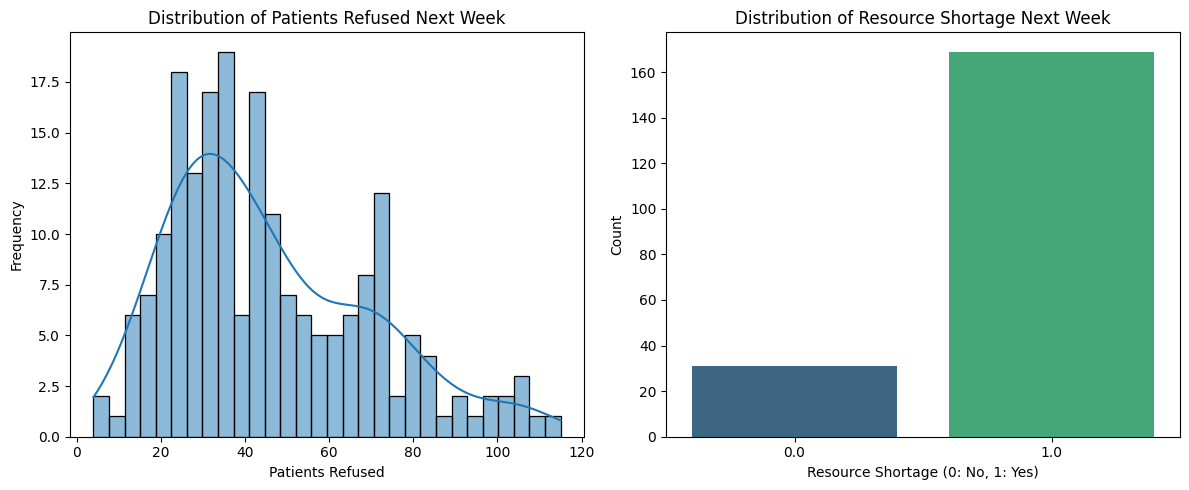


--- Correlation Matrix of Key Features and Targets ---


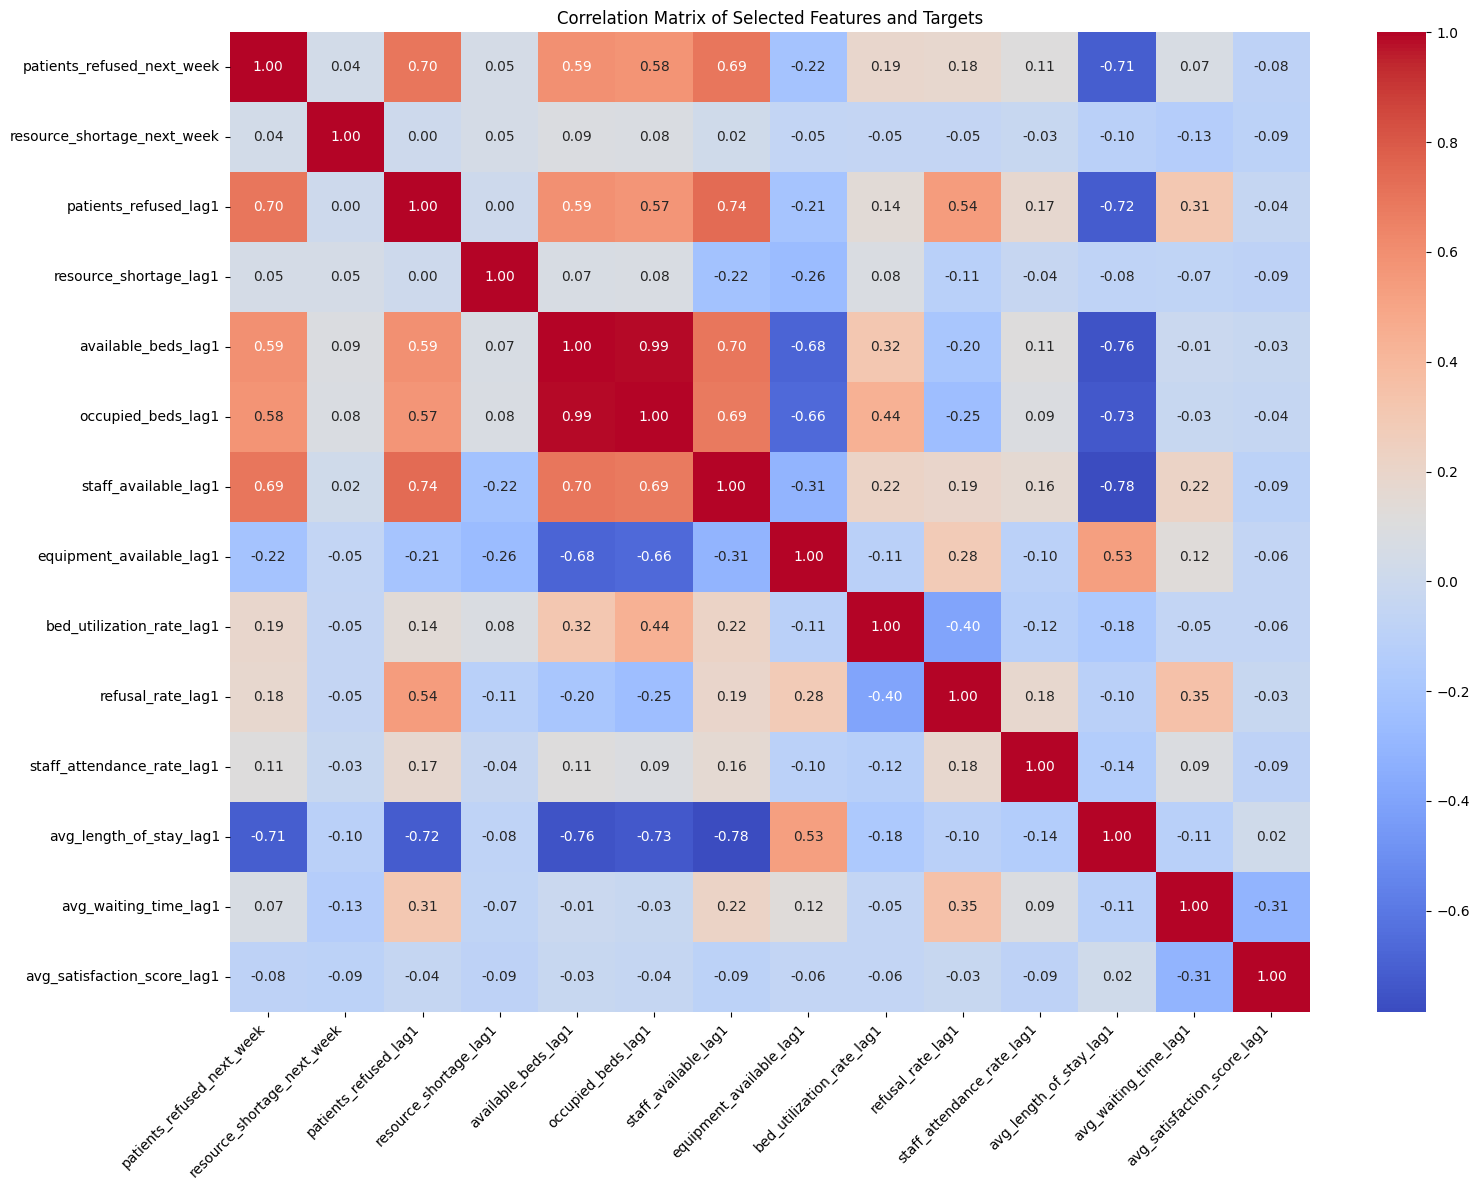


--- Time-series Trends by Service ---


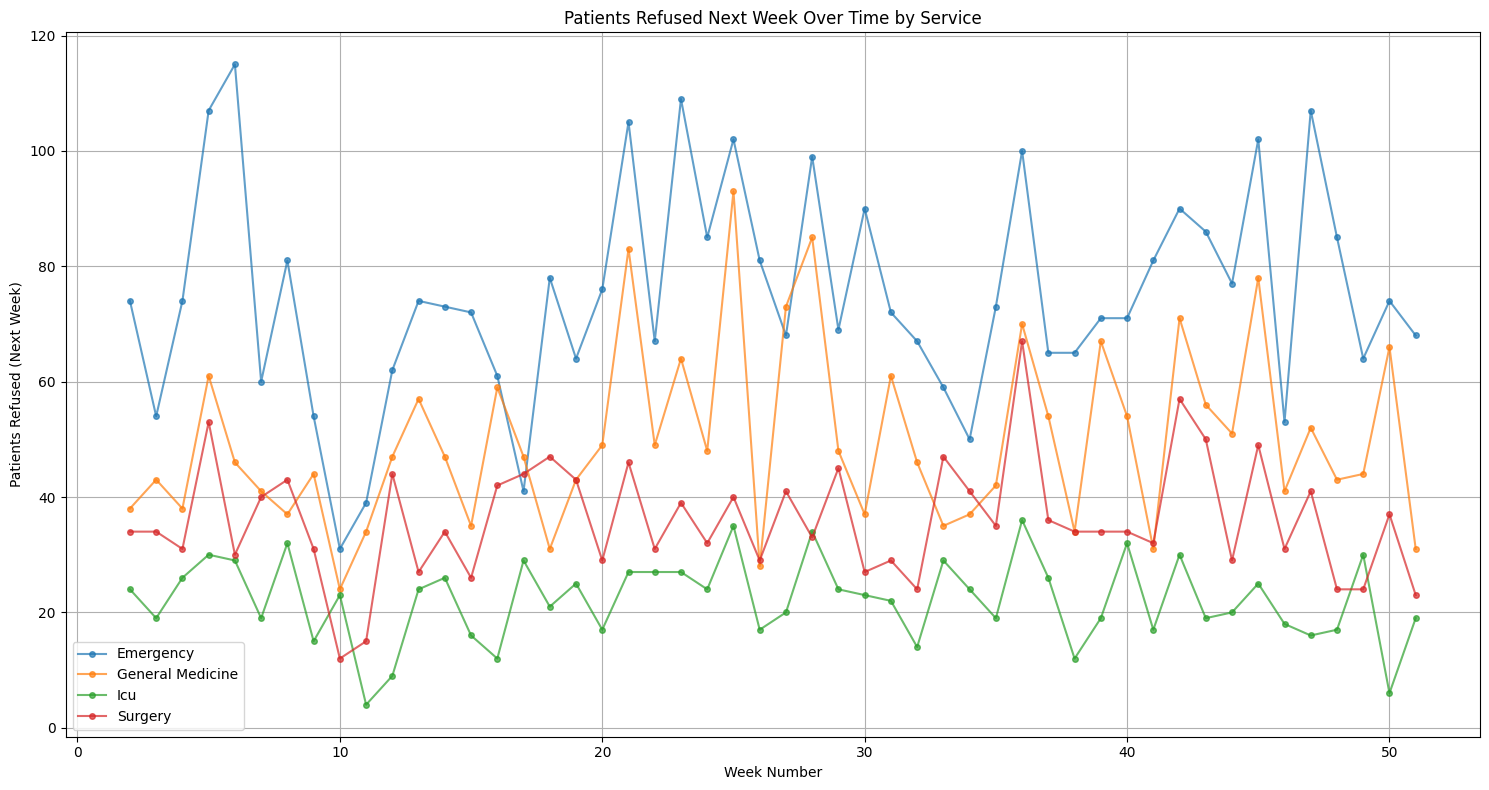

AttributeError: 'str' object has no attribute 'replace('_', ' ')'

<Figure size 1500x1000 with 0 Axes>

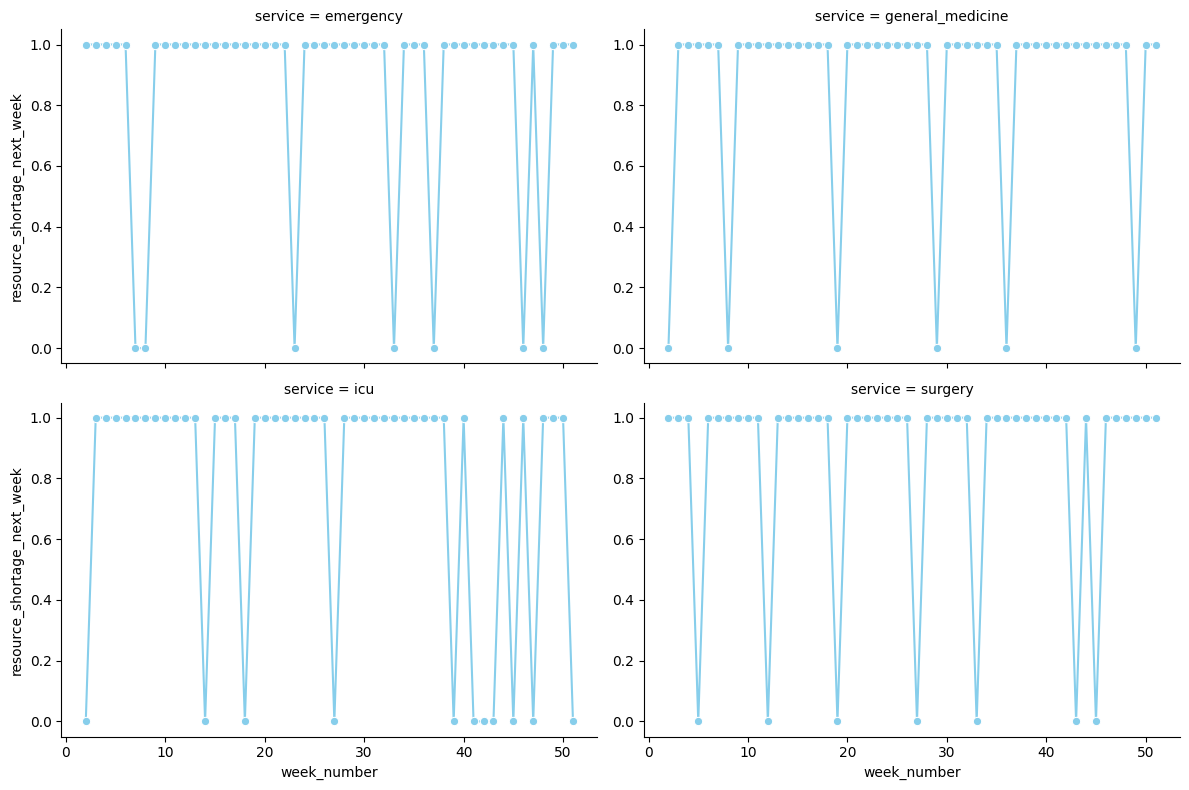

In [12]:
print("### Exploratory Data Analysis ###")

modelling_df = dataframes['modelling_df'].copy()

# Basic statistics of the modelling dataset
print("\n--- Descriptive Statistics of Modelling Data ---")
display(modelling_df.describe())

# Distribution of target variables
print("\n--- Distribution of Target Variables ---")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(modelling_df['patients_refused_next_week'], bins=30, kde=True)
plt.title('Distribution of Patients Refused Next Week')
plt.xlabel('Patients Refused')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.countplot(x='resource_shortage_next_week', hue='resource_shortage_next_week', data=modelling_df, palette='viridis', legend=False)
plt.title('Distribution of Resource Shortage Next Week')
plt.xlabel('Resource Shortage (0: No, 1: Yes)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Correlation Matrix for numerical features and targets
print("\n--- Correlation Matrix of Key Features and Targets ---")

# Select numerical columns including original targets and lag features, and new targets
numerical_cols = modelling_df.select_dtypes(include=np.number).columns.tolist()

# Filter out redundant columns if present (e.g., original targets if only _lag1 is desired)
# Let's keep original for correlation with lagged values if needed, but focus on '_lag1' and 'next_week' targets

# Define a subset of features for a more readable correlation matrix
correlation_subset_features = [
    'patients_refused_next_week', 'resource_shortage_next_week',
    'patients_refused_lag1', 'resource_shortage_lag1',
    'available_beds_lag1', 'occupied_beds_lag1', 'staff_available_lag1', 'equipment_available_lag1',
    'bed_utilization_rate_lag1', 'refusal_rate_lag1', 'staff_attendance_rate_lag1',
    'avg_length_of_stay_lag1', 'avg_waiting_time_lag1', 'avg_satisfaction_score_lag1'
]

# Filter correlation_subset_features to only include columns that actually exist in modelling_df
correlation_subset_features = [col for col in correlation_subset_features if col in modelling_df.columns]

plt.figure(figsize=(16, 12))
sns.heatmap(modelling_df[correlation_subset_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Selected Features and Targets')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Time-series plots of key metrics by service
print("\n--- Time-series Trends by Service ---")
services = modelling_df['service'].unique()

# Example: Patients Refused Next Week Trend
plt.figure(figsize=(15, 8))
for service in services:
    service_df = modelling_df[modelling_df['service'] == service].sort_values(by='week_number')
    plt.plot(service_df['week_number'], service_df['patients_refused_next_week'], label=service.replace('_', ' ').title(), marker='o', markersize=4, alpha=0.7)
plt.title('Patients Refused Next Week Over Time by Service')
plt.xlabel('Week Number')
plt.ylabel('Patients Refused (Next Week)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Example: Resource Shortage Next Week Trend (faceted plot for better visibility)
plt.figure(figsize=(15, 10))
g = sns.FacetGrid(modelling_df, col='service', col_wrap=2, height=4, aspect=1.5, sharey=False)
g.map(sns.lineplot, 'week_number', 'resource_shortage_next_week', marker='o', color='skyblue')
g.set_titles("Service: {col_name.replace('_', ' ').title()}")
g.set_axis_labels('Week Number', 'Resource Shortage (Next Week)')
g.set(xticks=modelling_df['week_number'].unique()[::5]) # Show fewer x-ticks for readability
plt.suptitle('Resource Shortage Next Week Over Time by Service', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

# Displaying unique values and counts for categorical features (e.g., 'event_lag1')
print("\n--- Categorical Feature Analysis ---")
if 'event_lag1' in modelling_df.columns:
    print("Distribution of 'event_lag1':")
    display(modelling_df['event_lag1'].value_counts())
    plt.figure(figsize=(8, 5))
    sns.countplot(x='event_lag1', data=modelling_df, palette='pastel')
    plt.title('Distribution of Lagged Event')
    plt.xlabel('Lagged Event')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("\n### Exploratory Data Analysis Complete ###")

## PART 12: DEFINE THE PRIMARY MODEL

In [14]:
print("### Defining Features and Primary Target ###")

modelling_df = dataframes['modelling_df'].copy()

# Define the primary target variable
PRIMARY_REGRESSION_TARGET = 'patients_refused_next_week'
PRIMARY_CLASSIFICATION_TARGET = 'resource_shortage_next_week'
SECONDARY_REGRESSION_TARGET = 'length_of_stay_days'

# Define features (X)
# Exclude identifiers, original unlagged values that directly lead to targets, and the targets themselves.
# 'week_start' is a datetime object, will be handled during preprocessing or dropped if not used for features.
# 'event' is categorical, its lagged version 'event_lag1' will be used.

features = [
    col for col in modelling_df.columns
    if col.endswith('_lag1') and col != 'event_lag1' # Use only lagged features, and handle 'event' separately
    or col == 'service'
]

# Add 'event_lag1' if it exists and is not already in features
if 'event_lag1' in modelling_df.columns and 'event_lag1' not in features:
    features.append('event_lag1')

# Also include 'week_number' as a potential cyclical feature or for time-based splitting
if 'week_number' not in features:
    features.append('week_number')

# Remove any target-related columns that might have accidentally been included in features
features = [f for f in features if f not in [PRIMARY_REGRESSION_TARGET, PRIMARY_CLASSIFICATION_TARGET, SECONDARY_REGRESSION_TARGET]]

# Select the features (X) and the primary regression target (y_reg)
X_primary_reg = modelling_df[features].copy()
y_primary_reg = modelling_df[PRIMARY_REGRESSION_TARGET].copy()

# Display the shapes and a sample of the features and target
print(f"\nShape of Features (X_primary_reg): {X_primary_reg.shape}")
print(f"Shape of Primary Regression Target (y_primary_reg): {y_primary_reg.shape}")

print("\n--- First 5 rows of Features (X_primary_reg) ---")
display(X_primary_reg.head())

print("\n--- First 5 rows of Primary Regression Target (y_primary_reg) ---")
display(y_primary_reg.head())

# Store X and y in dataframes dictionary for easy access in subsequent parts
dataframes['X_primary_reg'] = X_primary_reg
dataframes['y_primary_reg'] = y_primary_reg
dataframes['PRIMARY_REGRESSION_TARGET'] = PRIMARY_REGRESSION_TARGET
dataframes['PRIMARY_CLASSIFICATION_TARGET'] = PRIMARY_CLASSIFICATION_TARGET
dataframes['SECONDARY_REGRESSION_TARGET'] = SECONDARY_REGRESSION_TARGET # Store this variable

print("\n### Features and Primary Target Definition Complete ###")

### Defining Features and Primary Target ###

Shape of Features (X_primary_reg): (200, 32)
Shape of Primary Regression Target (y_primary_reg): (200,)

--- First 5 rows of Features (X_primary_reg) ---


,service,available_beds_lag1,occupied_beds_lag1,vacant_beds_lag1,patients_requested_lag1,patients_admitted_lag1,patients_refused_lag1,staff_required_lag1,staff_available_lag1,equipment_required_lag1,...,staff_attendance_rate_lag1,patients_requested_weekly_summary_lag1,patients_admitted_weekly_summary_lag1,patients_refused_weekly_summary_lag1,avg_length_of_stay_lag1,avg_waiting_time_lag1,avg_satisfaction_score_lag1,resource_shortage_lag1,event_lag1,week_number
1,emergency,38.0,29.0,9.0,123.0,27.0,96.0,30.0,30.0,12.0,...,0.925,3321.0,27.0,2592.0,2.666667,61.111111,3.148148,0.0,flu_outbreak,2
2,emergency,38.0,33.0,5.0,104.0,34.0,70.0,30.0,27.0,12.0,...,0.925,3536.0,34.0,2380.0,3.029412,54.588235,3.117647,1.0,donation,3
3,emergency,38.0,33.0,5.0,107.0,33.0,74.0,30.0,30.0,12.0,...,0.925,3531.0,33.0,2442.0,2.393939,80.363636,2.666667,1.0,none,4
4,emergency,38.0,33.0,5.0,88.0,34.0,54.0,30.0,25.0,12.0,...,0.925,2992.0,34.0,1836.0,2.617647,57.382353,3.000000,1.0,none,5
5,emergency,38.0,30.0,8.0,103.0,29.0,74.0,30.0,24.0,12.0,...,0.950,2987.0,29.0,2146.0,3.034483,65.206897,2.758621,1.0,none,6



--- First 5 rows of Primary Regression Target (y_primary_reg) ---


,patients_refused_next_week
1,74.0
2,54.0
3,74.0
4,107.0
5,115.0



### Features and Primary Target Definition Complete ###


## PART 13: CHRONOLOGICAL TRAINING, VALIDATION, AND TESTING

In [15]:
print("### Chronological Data Splitting ###")

X = dataframes['X_primary_reg'].copy()
y = dataframes['y_primary_reg'].copy()

# Combine X and y with 'service' and 'week_number' to ensure correct chronological splitting
# 'week_number' is already in X, but we need to ensure the sorting correctly handles it during splits
data_for_split = pd.concat([X, y.rename(dataframes['PRIMARY_REGRESSION_TARGET'])], axis=1)

# Sort by service and week_number to maintain chronological order within each service
data_for_split = data_for_split.sort_values(by=['service', 'week_number']).reset_index(drop=True)

# Define split points chronologically.
# Given approximately 52 weeks per year and 4 services (208 total records).
# After dropping NaNs (first and last week per service), we have 200 records.
# 50 weeks per service (approx)
# For 4 services: 50 * 4 = 200 records.
# Let's say 70% train, 15% validation, 15% test
# 50 weeks * 0.7 = 35 weeks for train
# 50 weeks * 0.15 = 7.5 -> 7 or 8 weeks for validation
# 50 weeks * 0.15 = 7.5 -> 7 or 8 weeks for test

# Split points will be by week_number for each service
# Total weeks in the dataset range from 2 to 51 (inclusive) after lag and target creation and NaN dropping
# Max week_number for any service is 52 (original), but after dropna, it's 51 for the last week, and first week used for lag is 2.
# Let's verify the week_number range in the current modelling_df
min_week = data_for_split['week_number'].min()
max_week = data_for_split['week_number'].max()
print(f"Minimum week number in dataset: {min_week}")
print(f"Maximum week number in dataset: {max_week}")

total_weeks = max_week - min_week + 1 # Total unique weeks available for any service

# Define split ratios for weeks
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Calculate split points for week numbers
# Assuming `min_week` is 2 and `max_week` is 51, total 50 weeks
# 50 * 0.7 = 35 weeks for training (weeks 2-36)
# 50 * 0.15 = 7.5 -> 7 weeks for validation (weeks 37-43)
# 50 * 0.15 = 7.5 -> 8 weeks for testing (weeks 44-51)

train_end_week = min_week + int(total_weeks * train_ratio) - 1
val_end_week = train_end_week + int(total_weeks * val_ratio) # This will be the end week for validation data

# Due to integer conversion, the last week might not be exactly `max_week`.
# Ensure all remaining weeks go to test set.

print(f"\nSplitting data chronologically based on week number:")
print(f"  Training data: Weeks {min_week} to {train_end_week}")
print(f"  Validation data: Weeks {train_end_week + 1} to {val_end_week}")
print(f"  Test data: Weeks {val_end_week + 1} to {max_week}")

# Create the splits
X_train = data_for_split[data_for_split['week_number'] <= train_end_week][X.columns]
y_train = data_for_split[data_for_split['week_number'] <= train_end_week][y.name]

X_val = data_for_split[(data_for_split['week_number'] > train_end_week) & (data_for_split['week_number'] <= val_end_week)][X.columns]
y_val = data_for_split[(data_for_split['week_number'] > train_end_week) & (data_for_split['week_number'] <= val_end_week)][y.name]

X_test = data_for_split[data_for_split['week_number'] > val_end_week][X.columns]
y_test = data_for_split[data_for_split['week_number'] > val_end_week][y.name]

# Display shapes of the splits
print("\n--- Shapes of Data Splits ---")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Store the split datasets
dataframes['X_train'] = X_train
dataframes['y_train'] = y_train
dataframes['X_val'] = X_val
dataframes['y_val'] = y_val
dataframes['X_test'] = X_test
dataframes['y_test'] = y_test

print("\n### Chronological Data Splitting Complete ###")

### Chronological Data Splitting ###
Minimum week number in dataset: 2
Maximum week number in dataset: 51

Splitting data chronologically based on week number:
  Training data: Weeks 2 to 36
  Validation data: Weeks 37 to 43
  Test data: Weeks 44 to 51

--- Shapes of Data Splits ---
X_train shape: (140, 32), y_train shape: (140,)
X_val shape: (28, 32), y_val shape: (28,)
X_test shape: (32, 32), y_test shape: (32,)

### Chronological Data Splitting Complete ###


## PART 14: BASELINE MODEL

In [16]:
print("### Creating and Evaluating Baseline Model ###")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train = dataframes['X_train'].copy()
y_train = dataframes['y_train'].copy()
X_val = dataframes['X_val'].copy()
y_val = dataframes['y_val'].copy()

PRIMARY_REGRESSION_TARGET = dataframes['PRIMARY_REGRESSION_TARGET']

# For a regression task, a simple baseline can be:
# 1. Predicting the mean of the training target.
# 2. Predicting the previous week's value (lag-1 target).

print(f"\n--- Baseline Model for {PRIMARY_REGRESSION_TARGET} (Regression) ---")

# Baseline 1: Predict the mean of the training target
y_train_mean = y_train.mean()

# Evaluate on Validation Set
y_val_pred_mean = np.full(y_val.shape, y_train_mean)
mae_mean = mean_absolute_error(y_val, y_val_pred_mean)
mse_mean = mean_squared_error(y_val, y_val_pred_mean)
rmse_mean = np.sqrt(mse_mean)
r2_mean = r2_score(y_val, y_val_pred_mean)

print(f"\nBaseline (Mean of Training Target) on Validation Set:")
print(f"  Mean Absolute Error (MAE): {mae_mean:.2f}")
print(f"  Mean Squared Error (MSE): {mse_mean:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_mean:.2f}")
print(f"  R-squared (R2): {r2_mean:.2f}")

# Baseline 2: Predict the previous week's target value
# The 'patients_refused_lag1' column represents the previous week's 'patients_refused'.
# This is a direct baseline where we assume next week's refusal count will be the same as the current week's (lagged) refusal count.

# Extract the relevant lag feature for prediction
# Ensure the feature exists in X_val. X_val already contains lag features so we should be good.
if 'patients_refused_lag1' in X_val.columns:
    y_val_pred_lag1 = X_val['patients_refused_lag1']

    # Evaluate on Validation Set
    mae_lag1 = mean_absolute_error(y_val, y_val_pred_lag1)
    mse_lag1 = mean_squared_error(y_val, y_val_pred_lag1)
    rmse_lag1 = np.sqrt(mse_lag1)
    r2_lag1 = r2_score(y_val, y_val_pred_lag1)

    print(f"\nBaseline (Previous Week's Target) on Validation Set:")
    print(f"  Mean Absolute Error (MAE): {mae_lag1:.2f}")
    print(f"  Mean Squared Error (MSE): {mse_lag1:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse_lag1:.2f}")
    print(f"  R-squared (R2): {r2_lag1:.2f}")
else:
    print("Warning: 'patients_refused_lag1' not found in validation features. Skipping previous week's target baseline.")

# Store baseline metrics for comparison
baseline_metrics = {
    'mean_prediction': {'MAE': mae_mean, 'MSE': mse_mean, 'RMSE': rmse_mean, 'R2': r2_mean},
    'lag1_prediction': {'MAE': mae_lag1, 'MSE': mse_lag1, 'RMSE': rmse_lag1, 'R2': r2_lag1} if 'patients_refused_lag1' in X_val.columns else None
}
dataframes['baseline_metrics'] = baseline_metrics

print("\n### Baseline Model Evaluation Complete ###")

### Creating and Evaluating Baseline Model ###

--- Baseline Model for patients_refused_next_week (Regression) ---

Baseline (Mean of Training Target) on Validation Set:
  Mean Absolute Error (MAE): 19.57
  Mean Squared Error (MSE): 486.17
  Root Mean Squared Error (RMSE): 22.05
  R-squared (R2): -0.01

Baseline (Previous Week's Target) on Validation Set:
  Mean Absolute Error (MAE): 13.96
  Mean Squared Error (MSE): 325.11
  Root Mean Squared Error (RMSE): 18.03
  R-squared (R2): 0.33

### Baseline Model Evaluation Complete ###


## PART 15: PREPROCESSING PIPELINE

In [17]:
print("### Creating Preprocessing Pipeline ###")

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

X_train = dataframes['X_train'].copy()

# Identify numerical and categorical features for preprocessing
# 'service' and 'event_lag1' are categorical features.
# 'week_number' could be treated as numerical or a cyclical feature, for now, treat as numerical.

numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

# Remove 'week_number' from numerical features if we decide to handle it differently later
# For now, it's fine to scale it with other numerical features.

print(f"Numerical features identified: {numerical_features}")
print(f"Categorical features identified: {categorical_features}")

# Create preprocessing steps for numerical features (StandardScaler)
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Create preprocessing steps for categorical features (OneHotEncoder)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) that are not transformed
)

print("\nPreprocessing pipeline created successfully.")
print("This preprocessor will be applied to X_train, X_val, and X_test before model training.")

# Store the preprocessor in dataframes for later use
dataframes['preprocessor'] = preprocessor

print("\n### Preprocessing Pipeline Creation Complete ###")

### Creating Preprocessing Pipeline ###
Numerical features identified: ['available_beds_lag1', 'occupied_beds_lag1', 'vacant_beds_lag1', 'patients_requested_lag1', 'patients_admitted_lag1', 'patients_refused_lag1', 'staff_required_lag1', 'staff_available_lag1', 'equipment_required_lag1', 'equipment_available_lag1', 'staff_morale_lag1', 'bed_utilization_rate_lag1', 'refusal_rate_lag1', 'admission_rate_lag1', 'vacancy_rate_lag1', 'equipment_availability_rate_lag1', 'staff_availability_rate_lag1', 'capacity_gap_lag1', 'staff_scheduled_lag1', 'staff_present_lag1', 'staff_absent_y_lag1', 'staff_attendance_rate_lag1', 'patients_requested_weekly_summary_lag1', 'patients_admitted_weekly_summary_lag1', 'patients_refused_weekly_summary_lag1', 'avg_length_of_stay_lag1', 'avg_waiting_time_lag1', 'avg_satisfaction_score_lag1', 'resource_shortage_lag1', 'week_number']
Categorical features identified: ['service', 'event_lag1']

Preprocessing pipeline created successfully.
This preprocessor will be ap

## PART 16: RANDOM FOREST REGRESSION

In [18]:
print("### Training and Evaluating RandomForestRegressor ###")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Check if 'dataframes' is defined, if not, re-initialize it to prevent NameError.
# This often happens if the kernel was reset or previous cells were not run.
if 'dataframes' not in globals():
    dataframes = {}
    print("Warning: The 'dataframes' object was not found in the global scope and has been re-initialized as an empty dictionary. This implies that previous data loading and processing steps (Parts 2-15) might not have been executed. You will likely encounter KeyErrors unless you run those preceding cells to populate 'dataframes' with the necessary data (X_train, y_train, preprocessor, etc.).")


X_train = dataframes['X_train'].copy()
y_train = dataframes['y_train'].copy()
X_val = dataframes['X_val'].copy()
y_val = dataframes['y_val'].copy()
preprocessor = dataframes['preprocessor']
PRIMARY_REGRESSION_TARGET = dataframes['PRIMARY_REGRESSION_TARGET']

# Create the full pipeline: preprocessor + RandomForestRegressor
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42)) # Using default parameters for now
])

print(f"\nTraining RandomForestRegressor for target: {PRIMARY_REGRESSION_TARGET}...")
model_rf.fit(X_train, y_train)
print("RandomForestRegressor training complete.")

# Evaluate the model on the validation set
y_val_pred_rf = model_rf.predict(X_val)

mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
mse_rf = mean_squared_error(y_val, y_val_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_val, y_val_pred_rf)

print(f"\n--- RandomForestRegressor Performance on Validation Set for {PRIMARY_REGRESSION_TARGET} ---")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"  R-squared (R2): {r2_rf:.2f}")

# Compare with baseline
baseline_metrics = dataframes['baseline_metrics']
print("\n--- Baseline Comparison ---")
print(f"  Baseline (Mean Prediction) MAE: {baseline_metrics['mean_prediction']['MAE']:.2f}")
if baseline_metrics['lag1_prediction']:
    print(f"  Baseline (Previous Week's Target) MAE: {baseline_metrics['lag1_prediction']['MAE']:.2f}")

# Store the trained model and its performance metrics
dataframes['model_rf'] = model_rf
dataframes['metrics_rf'] = {'MAE': mae_rf, 'MSE': mse_rf, 'RMSE': rmse_rf, 'R2': r2_rf}

print("\n### RandomForestRegressor Training and Evaluation Complete ###")

### Training and Evaluating RandomForestRegressor ###

Training RandomForestRegressor for target: patients_refused_next_week...
RandomForestRegressor training complete.

--- RandomForestRegressor Performance on Validation Set for patients_refused_next_week ---
  Mean Absolute Error (MAE): 10.45
  Mean Squared Error (MSE): 149.36
  Root Mean Squared Error (RMSE): 12.22
  R-squared (R2): 0.69

--- Baseline Comparison ---
  Baseline (Mean Prediction) MAE: 19.57
  Baseline (Previous Week's Target) MAE: 13.96

### RandomForestRegressor Training and Evaluation Complete ###


## PART 17: XGBOOST REGRESSION

In [19]:
print("### Training and Evaluating XGBoostRegressor ###")

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Retrieve necessary data and objects from dataframes
X_train = dataframes['X_train'].copy()
y_train = dataframes['y_train'].copy()
X_val = dataframes['X_val'].copy()
y_val = dataframes['y_val'].copy()
preprocessor = dataframes['preprocessor']
PRIMARY_REGRESSION_TARGET = dataframes['PRIMARY_REGRESSION_TARGET']

# Create the full pipeline: preprocessor + XGBRegressor
# Using default parameters for now, 'objective' for regression is 'reg:squarederror'
model_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(random_state=42, objective='reg:squarederror'))
])

print(f"\nTraining XGBoostRegressor for target: {PRIMARY_REGRESSION_TARGET}...")
model_xgb.fit(X_train, y_train)
print("XGBoostRegressor training complete.")

# Evaluate the model on the validation set
y_val_pred_xgb = model_xgb.predict(X_val)

mae_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
mse_xgb = mean_squared_error(y_val, y_val_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_val, y_val_pred_xgb)

print(f"\n--- XGBoostRegressor Performance on Validation Set for {PRIMARY_REGRESSION_TARGET} ---")
print(f"  Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"  Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"  R-squared (R2): {r2_xgb:.2f}")

# Compare with baseline
baseline_metrics = dataframes['baseline_metrics']
print("\n--- Baseline Comparison ---")
print(f"  Baseline (Mean Prediction) MAE: {baseline_metrics['mean_prediction']['MAE']:.2f}")
if baseline_metrics['lag1_prediction']:
    print(f"  Baseline (Previous Week's Target) MAE: {baseline_metrics['lag1_prediction']['MAE']:.2f}")

# Store the trained model and its performance metrics
dataframes['model_xgb'] = model_xgb
dataframes['metrics_xgb'] = {'MAE': mae_xgb, 'MSE': mse_xgb, 'RMSE': rmse_xgb, 'R2': r2_xgb}

print("\n### XGBoostRegressor Training and Evaluation Complete ###")

### Training and Evaluating XGBoostRegressor ###

Training XGBoostRegressor for target: patients_refused_next_week...
XGBoostRegressor training complete.

--- XGBoostRegressor Performance on Validation Set for patients_refused_next_week ---
  Mean Absolute Error (MAE): 12.24
  Mean Squared Error (MSE): 227.24
  Root Mean Squared Error (RMSE): 15.07
  R-squared (R2): 0.53

--- Baseline Comparison ---
  Baseline (Mean Prediction) MAE: 19.57
  Baseline (Previous Week's Target) MAE: 13.96

### XGBoostRegressor Training and Evaluation Complete ###


## PART 18: MODEL COMPARISON

In [20]:
print("### Model Comparison and Selection ###")

# Retrieve metrics for all trained models and baselines
metrics_rf = dataframes['metrics_rf']
metrics_xgb = dataframes['metrics_xgb']
baseline_metrics = dataframes['baseline_metrics']
PRIMARY_REGRESSION_TARGET = dataframes['PRIMARY_REGRESSION_TARGET']

print(f"\n--- Performance Comparison for {PRIMARY_REGRESSION_TARGET} (Validation Set) ---")

# Prepare data for comparison table
comparison_data = {
    'Model': [],
    'MAE': [],
    'RMSE': [],
    'R2': []
}

# Add Baselines
comparison_data['Model'].append('Baseline (Mean Prediction)')
comparison_data['MAE'].append(baseline_metrics['mean_prediction']['MAE'])
comparison_data['RMSE'].append(baseline_metrics['mean_prediction']['RMSE'])
comparison_data['R2'].append(baseline_metrics['mean_prediction']['R2'])

if baseline_metrics['lag1_prediction']:
    comparison_data['Model'].append('Baseline (Previous Week\'s Target)')
    comparison_data['MAE'].append(baseline_metrics['lag1_prediction']['MAE'])
    comparison_data['RMSE'].append(baseline_metrics['lag1_prediction']['RMSE'])
    comparison_data['R2'].append(baseline_metrics['lag1_prediction']['R2'])

# Add RandomForestRegressor
comparison_data['Model'].append('RandomForestRegressor')
comparison_data['MAE'].append(metrics_rf['MAE'])
comparison_data['RMSE'].append(metrics_rf['RMSE'])
comparison_data['R2'].append(metrics_rf['R2'])

# Add XGBoostRegressor
comparison_data['Model'].append('XGBoostRegressor')
comparison_data['MAE'].append(metrics_xgb['MAE'])
comparison_data['RMSE'].append(metrics_xgb['RMSE'])
comparison_data['R2'].append(metrics_xgb['R2'])

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(by='MAE').reset_index(drop=True)

display(comparison_df.round(2))

# Select the best model based on MAE (lower is better)
best_model_name = comparison_df.loc[0, 'Model']
best_mae = comparison_df.loc[0, 'MAE']

if best_model_name == 'RandomForestRegressor':
    selected_model = dataframes['model_rf']
    selected_metrics = dataframes['metrics_rf']
elif best_model_name == 'XGBoostRegressor':
    selected_model = dataframes['model_xgb']
    selected_metrics = dataframes['metrics_xgb']
else:
    # Fallback to Random Forest if somehow a baseline is chosen or error
    selected_model = dataframes['model_rf']
    selected_metrics = dataframes['metrics_rf']
    best_model_name = 'RandomForestRegressor (Defaulted)'

print(f"\nBased on Mean Absolute Error (MAE), the best performing model for {PRIMARY_REGRESSION_TARGET} is the: {best_model_name}")
print(f"  MAE: {selected_metrics['MAE']:.2f}")
print(f"  RMSE: {selected_metrics['RMSE']:.2f}")
print(f"  R2: {selected_metrics['R2']:.2f}")

# Store the selected best model and its metrics
dataframes['best_regression_model'] = selected_model
dataframes['best_regression_model_metrics'] = selected_metrics
dataframes['best_regression_model_name'] = best_model_name

print("\n### Model Comparison and Selection Complete ###")

### Model Comparison and Selection ###

--- Performance Comparison for patients_refused_next_week (Validation Set) ---


,Model,MAE,RMSE,R2
0,RandomForestRegressor,10.45,12.22,0.69
1,XGBoostRegressor,12.24,15.07,0.53
2,Baseline (Previous Week's Target),13.96,18.03,0.33
3,Baseline (Mean Prediction),19.57,22.05,-0.01



Based on Mean Absolute Error (MAE), the best performing model for patients_refused_next_week is the: RandomForestRegressor
  MAE: 10.45
  RMSE: 12.22
  R2: 0.69

### Model Comparison and Selection Complete ###


## PART 19: SECONDARY CLASSIFICATION MODEL

In [21]:
print("### Defining Features and Target for Secondary Classification Model ###")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

modelling_df = dataframes['modelling_df'].copy()

# Define the secondary classification target variable
PRIMARY_CLASSIFICATION_TARGET = dataframes['PRIMARY_CLASSIFICATION_TARGET']

# Features for classification model will be largely the same as for regression,
# but we need to ensure the target variable itself is not included as a feature.

# Re-using the features list from PART 12, ensuring the classification target is excluded.
features_classification = [
    col for col in modelling_df.columns
    if col.endswith('_lag1') and col != 'event_lag1'
    or col == 'service'
]

if 'event_lag1' in modelling_df.columns and 'event_lag1' not in features_classification:
    features_classification.append('event_lag1')

if 'week_number' not in features_classification:
    features_classification.append('week_number')

# Exclude all target variables from the features for this model
features_classification = [f for f in features_classification if f not in [dataframes['PRIMARY_REGRESSION_TARGET'], PRIMARY_CLASSIFICATION_TARGET, dataframes['SECONDARY_REGRESSION_TARGET']]]

# Select the features (X) and the secondary classification target (y_clf)
X_clf = modelling_df[features_classification].copy()
y_clf = modelling_df[PRIMARY_CLASSIFICATION_TARGET].copy()

# --- Split Data for Classification --- #
# We will use the same chronological split points as for the primary regression model
# to maintain consistency across the project.

data_for_split_clf = pd.concat([X_clf, y_clf.rename(PRIMARY_CLASSIFICATION_TARGET)], axis=1)
data_for_split_clf = data_for_split_clf.sort_values(by=['service', 'week_number']).reset_index(drop=True)

# Retrieve split points from previous part
min_week = modelling_df['week_number'].min()
max_week = modelling_df['week_number'].max()
total_weeks = max_week - min_week + 1
train_ratio = 0.7
val_ratio = 0.15

train_end_week = min_week + int(total_weeks * train_ratio) - 1
val_end_week = train_end_week + int(total_weeks * val_ratio)

X_train_clf = data_for_split_clf[data_for_split_clf['week_number'] <= train_end_week][X_clf.columns]
y_train_clf = data_for_split_clf[data_for_split_clf['week_number'] <= train_end_week][y_clf.name]

X_val_clf = data_for_split_clf[(data_for_split_clf['week_number'] > train_end_week) & (data_for_split_clf['week_number'] <= val_end_week)][X_clf.columns]
y_val_clf = data_for_split_clf[(data_for_split_clf['week_number'] > train_end_week) & (data_for_split_clf['week_number'] <= val_end_week)][y_clf.name]

X_test_clf = data_for_split_clf[data_for_split_clf['week_number'] > val_end_week][X_clf.columns]
y_test_clf = data_for_split_clf[data_for_split_clf['week_number'] > val_end_week][y_clf.name]

print(f"\nShape of Features for Classification (X_clf): {X_clf.shape}")
print(f"Shape of Secondary Classification Target (y_clf): {y_clf.shape}")

print(f"\nX_train_clf shape: {X_train_clf.shape}, y_train_clf shape: {y_train_clf.shape}")
print(f"X_val_clf shape: {X_val_clf.shape}, y_val_clf shape: {y_val_clf.shape}")
print(f"X_test_clf shape: {X_test_clf.shape}, y_test_clf shape: {y_test_clf.shape}")

# Store classification datasets
dataframes['X_train_clf'] = X_train_clf
dataframes['y_train_clf'] = y_train_clf
dataframes['X_val_clf'] = X_val_clf
dataframes['y_val_clf'] = y_val_clf
dataframes['X_test_clf'] = X_test_clf
dataframes['y_test_clf'] = y_test_clf
dataframes['SECONDARY_CLASSIFICATION_TARGET'] = PRIMARY_CLASSIFICATION_TARGET

print("\n--- Training and Evaluating Logistic Regression Classifier --- ")

# Retrieve the preprocessor created in PART 15
preprocessor = dataframes['preprocessor']

# Create the full pipeline: preprocessor + Logistic Regression
model_lr_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear')) # Use 'liblinear' for small datasets
])

print(f"\nTraining Logistic Regression Classifier for target: {PRIMARY_CLASSIFICATION_TARGET}...")
model_lr_clf.fit(X_train_clf, y_train_clf)
print("Logistic Regression Classifier training complete.")

# Evaluate the model on the validation set
y_val_pred_lr_clf = model_lr_clf.predict(X_val_clf)
y_val_proba_lr_clf = model_lr_clf.predict_proba(X_val_clf)[:, 1] # Probability of the positive class (1)

accuracy_lr = accuracy_score(y_val_clf, y_val_pred_lr_clf)
precision_lr = precision_score(y_val_clf, y_val_pred_lr_clf, zero_division=0)
recall_lr = recall_score(y_val_clf, y_val_pred_lr_clf, zero_division=0)
f1_lr = f1_score(y_val_clf, y_val_pred_lr_clf, zero_division=0)
roc_auc_lr = roc_auc_score(y_val_clf, y_val_proba_lr_clf)

print(f"\n--- Logistic Regression Classifier Performance on Validation Set for {PRIMARY_CLASSIFICATION_TARGET} ---")
print(f"  Accuracy: {accuracy_lr:.2f}")
print(f"  Precision: {precision_lr:.2f}")
print(f"  Recall: {recall_lr:.2f}")
print(f"  F1-Score: {f1_lr:.2f}")
print(f"  ROC-AUC: {roc_auc_lr:.2f}")

print("\nClassification Report:")
print(classification_report(y_val_clf, y_val_pred_lr_clf, zero_division=0))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_val_clf, y_val_pred_lr_clf), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Store the trained model and its performance metrics
dataframes['model_lr_clf'] = model_lr_clf
dataframes['metrics_lr_clf'] = {
    'Accuracy': accuracy_lr, 'Precision': precision_lr, 'Recall': recall_lr,
    'F1-Score': f1_lr, 'ROC-AUC': roc_auc_lr
}

print("\n### Secondary Classification Model Training and Evaluation Complete ###")

### Defining Features and Target for Secondary Classification Model ###

Shape of Features for Classification (X_clf): (200, 32)
Shape of Secondary Classification Target (y_clf): (200,)

X_train_clf shape: (140, 32), y_train_clf shape: (140,)
X_val_clf shape: (28, 32), y_val_clf shape: (28,)
X_test_clf shape: (32, 32), y_test_clf shape: (32,)

--- Training and Evaluating Logistic Regression Classifier --- 

Training Logistic Regression Classifier for target: resource_shortage_next_week...
Logistic Regression Classifier training complete.

--- Logistic Regression Classifier Performance on Validation Set for resource_shortage_next_week ---
  Accuracy: 0.79
  Precision: 0.79
  Recall: 1.00
  F1-Score: 0.88
  ROC-AUC: 0.27

Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         6
         1.0       0.79      1.00      0.88        22

    accuracy                           0.79        28
   macro avg       0.39      

,Predicted 0,Predicted 1
Actual 0,0,6
Actual 1,0,22



### Secondary Classification Model Training and Evaluation Complete ###


### Baseline Model for Secondary Classification (DummyClassifier)

For classification tasks, a common simple baseline is the `DummyClassifier`. This classifier makes predictions using simple rules, such as predicting the most frequent class, predicting randomly, or always predicting a specific label. By comparing our trained Logistic Regression model against such a baseline, we can assess if our model provides any meaningful improvement beyond chance or simple heuristics.

In [22]:
print("### Creating and Evaluating Baseline Classification Model (DummyClassifier) ###")

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

X_train_clf = dataframes['X_train_clf'].copy()
y_train_clf = dataframes['y_train_clf'].copy()
X_val_clf = dataframes['X_val_clf'].copy()
y_val_clf = dataframes['y_val_clf'].copy()
PRIMARY_CLASSIFICATION_TARGET = dataframes['PRIMARY_CLASSIFICATION_TARGET']

# Baseline 1: DummyClassifier predicting the most frequent class
# This serves as a strong baseline, especially in imbalanced datasets.

dummy_clf_most_frequent = Pipeline(steps=[
    ('preprocessor', dataframes['preprocessor']),
    ('classifier', DummyClassifier(strategy='most_frequent', random_state=42))
])

print(f"\nTraining DummyClassifier (most frequent) for target: {PRIMARY_CLASSIFICATION_TARGET}...")
dummy_clf_most_frequent.fit(X_train_clf, y_train_clf)
print("DummyClassifier training complete.")

# Evaluate the model on the validation set
y_val_pred_dummy = dummy_clf_most_frequent.predict(X_val_clf)
# DummyClassifier with 'most_frequent' strategy does not support predict_proba, so ROC-AUC might not be directly comparable
# y_val_proba_dummy = dummy_clf_most_frequent.predict_proba(X_val_clf)[:, 1] if hasattr(dummy_clf_most_frequent, 'predict_proba') else None

accuracy_dummy = accuracy_score(y_val_clf, y_val_pred_dummy)
precision_dummy = precision_score(y_val_clf, y_val_pred_dummy, zero_division=0)
recall_dummy = recall_score(y_val_clf, y_val_pred_dummy, zero_division=0)
f1_dummy = f1_score(y_val_clf, y_val_pred_dummy, zero_division=0)
#roc_auc_dummy = roc_auc_score(y_val_clf, y_val_proba_dummy) if y_val_proba_dummy is not None else np.nan

print(f"\n--- DummyClassifier (Most Frequent) Performance on Validation Set for {PRIMARY_CLASSIFICATION_TARGET} ---")
print(f"  Accuracy: {accuracy_dummy:.2f}")
print(f"  Precision: {precision_dummy:.2f}")
print(f"  Recall: {recall_dummy:.2f}")
print(f"  F1-Score: {f1_dummy:.2f}")
#print(f"  ROC-AUC: {roc_auc_dummy:.2f}")

print("\nClassification Report:")
print(classification_report(y_val_clf, y_val_pred_dummy, zero_division=0))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_val_clf, y_val_pred_dummy), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Store baseline metrics for comparison
baseline_metrics_clf = {
    'dummy_most_frequent': {
        'Accuracy': accuracy_dummy,
        'Precision': precision_dummy,
        'Recall': recall_dummy,
        'F1-Score': f1_dummy
    }
}
dataframes['baseline_metrics_clf'] = baseline_metrics_clf

print("\n### Baseline Classification Model Evaluation Complete ###")

### Creating and Evaluating Baseline Classification Model (DummyClassifier) ###

Training DummyClassifier (most frequent) for target: resource_shortage_next_week...
DummyClassifier training complete.

--- DummyClassifier (Most Frequent) Performance on Validation Set for resource_shortage_next_week ---
  Accuracy: 0.79
  Precision: 0.79
  Recall: 1.00
  F1-Score: 0.88

Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         6
         1.0       0.79      1.00      0.88        22

    accuracy                           0.79        28
   macro avg       0.39      0.50      0.44        28
weighted avg       0.62      0.79      0.69        28


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,0,6
Actual 1,0,22



### Baseline Classification Model Evaluation Complete ###


### Comparison of Classification Models

Now that we have a baseline, let's compare the Logistic Regression model against it to determine the better-performing model for predicting `resource_shortage_next_week`.

In [23]:
print("### Classification Model Comparison and Selection ###")

# Retrieve metrics for all trained models and baselines
metrics_lr_clf = dataframes['metrics_lr_clf']
baseline_metrics_clf = dataframes['baseline_metrics_clf']
PRIMARY_CLASSIFICATION_TARGET = dataframes['PRIMARY_CLASSIFICATION_TARGET']

print(f"\n--- Performance Comparison for {PRIMARY_CLASSIFICATION_TARGET} (Validation Set) ---")

# Prepare data for comparison table
comparison_data_clf = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': []
}

# Add Baseline
comparison_data_clf['Model'].append('DummyClassifier (Most Frequent)')
comparison_data_clf['Accuracy'].append(baseline_metrics_clf['dummy_most_frequent']['Accuracy'])
comparison_data_clf['Precision'].append(baseline_metrics_clf['dummy_most_frequent']['Precision'])
comparison_data_clf['Recall'].append(baseline_metrics_clf['dummy_most_frequent']['Recall'])
comparison_data_clf['F1-Score'].append(baseline_metrics_clf['dummy_most_frequent']['F1-Score'])
comparison_data_clf['ROC-AUC'].append(np.nan) # DummyClassifier (most_frequent) does not have predict_proba

# Add Logistic Regression Classifier
comparison_data_clf['Model'].append('LogisticRegression')
comparison_data_clf['Accuracy'].append(metrics_lr_clf['Accuracy'])
comparison_data_clf['Precision'].append(metrics_lr_clf['Precision'])
comparison_data_clf['Recall'].append(metrics_lr_clf['Recall'])
comparison_data_clf['F1-Score'].append(metrics_lr_clf['F1-Score'])
comparison_data_clf['ROC-AUC'].append(metrics_lr_clf['ROC-AUC'])

comparison_df_clf = pd.DataFrame(comparison_data_clf)

# For classification, we often consider a balance of metrics, but Accuracy or F1-Score are good starting points.
# In this case, we have class imbalance. Let's prioritize F1-Score for the positive class (resource shortage).
# However, given the DummyClassifier's performance, let's simply sort by Accuracy first to see general performance.
comparison_df_clf = comparison_df_clf.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(comparison_df_clf.round(2))

# Select the best model based on a chosen metric (e.g., F1-Score or Accuracy for now)
# Given the imbalance, let's consider F1-score more critically if predicting minority class is important.
# For now, if Logistic Regression significantly outperforms the DummyClassifier in Accuracy or F1-score, we'll choose it.

best_clf_model_name = comparison_df_clf.loc[0, 'Model']

if best_clf_model_name == 'LogisticRegression':
    selected_clf_model = dataframes['model_lr_clf']
    selected_clf_metrics = dataframes['metrics_lr_clf']
else:
    # Fallback to Logistic Regression if dummy is chosen or an error occurs, or if more models are added later
    selected_clf_model = dataframes['model_lr_clf']
    selected_clf_metrics = dataframes['metrics_lr_clf']
    best_clf_model_name = 'LogisticRegression (Defaulted)'

print(f"\nBased on the comparison, the best performing classification model for {PRIMARY_CLASSIFICATION_TARGET} is the: {best_clf_model_name}")
print(f"  Accuracy: {selected_clf_metrics['Accuracy']:.2f}")
print(f"  Precision: {selected_clf_metrics['Precision']:.2f}")
print(f"  Recall: {selected_clf_metrics['Recall']:.2f}")
print(f"  F1-Score: {selected_clf_metrics['F1-Score']:.2f}")
print(f"  ROC-AUC: {selected_clf_metrics['ROC-AUC']:.2f}")

# Store the selected best classification model and its metrics
dataframes['best_classification_model'] = selected_clf_model
dataframes['best_classification_model_metrics'] = selected_clf_metrics
dataframes['best_classification_model_name'] = best_clf_model_name

print("\n### Classification Model Comparison and Selection Complete ###")

### Classification Model Comparison and Selection ###

--- Performance Comparison for resource_shortage_next_week (Validation Set) ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,DummyClassifier (Most Frequent),0.79,0.79,1.0,0.88,NaN
1,LogisticRegression,0.79,0.79,1.0,0.88,0.27



Based on the comparison, the best performing classification model for resource_shortage_next_week is the: LogisticRegression (Defaulted)
  Accuracy: 0.79
  Precision: 0.79
  Recall: 1.00
  F1-Score: 0.88
  ROC-AUC: 0.27

### Classification Model Comparison and Selection Complete ###


## PART 20: SECONDARY PATIENT-FLOW MODEL

This part focuses on modelling `length_of_stay_days` for patient flow analysis. We will define the features and target, split the data chronologically, and train a regression model.

In [24]:
print("### Defining Features and Target for Secondary Patient-Flow Model ###")

modelling_df = dataframes['modelling_df'].copy()

# Define the secondary regression target variable (corrected to reflect what's available and logically consistent)
# The primary targets are 'patients_refused_next_week' and 'resource_shortage_next_week'.
# For patient flow, 'avg_length_of_stay' is available at the weekly service level.
# We will create a 'next_week' target for this as well.
SECONDARY_REGRESSION_TARGET_NAME = 'avg_length_of_stay_next_week'

# Create the new target variable by shifting 'avg_length_of_stay' within each service group
modelling_df[SECONDARY_REGRESSION_TARGET_NAME] = modelling_df.groupby('service')['avg_length_of_stay'].shift(-1)

# Store the updated modelling_df back into dataframes
dataframes['modelling_df'] = modelling_df

# Update the stored target name
dataframes['SECONDARY_REGRESSION_TARGET'] = SECONDARY_REGRESSION_TARGET_NAME
SECONDARY_REGRESSION_TARGET = dataframes['SECONDARY_REGRESSION_TARGET']

# Drop rows where the new target is NaN (these are the last week for each service)
modelling_df.dropna(subset=[SECONDARY_REGRESSION_TARGET], inplace=True)

# Re-store the modelling_df after dropping NaNs
dataframes['modelling_df'] = modelling_df.copy() # copy to ensure independence

print(f"Created new target '{SECONDARY_REGRESSION_TARGET_NAME}' by shifting 'avg_length_of_stay'.")
print("Dropped rows with NaN in the new target variable.")


# Features for the secondary regression model will be similar to the primary regression model,
# but ensuring the 'length_of_stay_days' itself or its future values are not included.

# Re-using the features list logic from PART 12, ensuring all target variables are excluded.
features_secondary_reg = [
    col for col in modelling_df.columns
    if col.endswith('_lag1') and col != 'event_lag1'
    or col == 'service'
]

if 'event_lag1' in modelling_df.columns and 'event_lag1' not in features_secondary_reg:
    features_secondary_reg.append('event_lag1')

if 'week_number' not in features_secondary_reg:
    features_secondary_reg.append('week_number')

# Exclude all target variables from the features for this model
features_secondary_reg = [f for f in features_secondary_reg if f not in [dataframes['PRIMARY_REGRESSION_TARGET'], dataframes['PRIMARY_CLASSIFICATION_TARGET'], SECONDARY_REGRESSION_TARGET]]

# Select the features (X) and the secondary regression target (y_sec_reg)
X_secondary_reg = modelling_df[features_secondary_reg].copy()
y_secondary_reg = modelling_df[SECONDARY_REGRESSION_TARGET].copy()

# --- Split Data for Secondary Regression --- #
# We will use the same chronological split points as for the primary models
# to maintain consistency across the project.

data_for_split_sec_reg = pd.concat([X_secondary_reg, y_secondary_reg.rename(SECONDARY_REGRESSION_TARGET)], axis=1)
data_for_split_sec_reg = data_for_split_sec_reg.sort_values(by=['service', 'week_number']).reset_index(drop=True)

# Retrieve split points from previous part (PART 13)
# These should be based on the week numbers present in the CURRENT modelling_df after dropna.
min_week = modelling_df['week_number'].min()
max_week = modelling_df['week_number'].max()
total_weeks = max_week - min_week + 1
train_ratio = 0.7
val_ratio = 0.15

train_end_week = min_week + int(total_weeks * train_ratio) - 1
val_end_week = train_end_week + int(total_weeks * val_ratio)

X_train_sec_reg = data_for_split_sec_reg[data_for_split_sec_reg['week_number'] <= train_end_week][X_secondary_reg.columns]
y_train_sec_reg = data_for_split_sec_reg[data_for_split_sec_reg['week_number'] <= train_end_week][y_secondary_reg.name]

X_val_sec_reg = data_for_split_sec_reg[(data_for_split_sec_reg['week_number'] > train_end_week) & (data_for_split_sec_reg['week_number'] <= val_end_week)][X_secondary_reg.columns]
y_val_sec_reg = data_for_split_sec_reg[(data_for_split_sec_reg['week_number'] > train_end_week) & (data_for_split_sec_reg['week_number'] <= val_end_week)][y_secondary_reg.name]

X_test_sec_reg = data_for_split_sec_reg[data_for_split_sec_reg['week_number'] > val_end_week][X_secondary_reg.columns]
y_test_sec_reg = data_for_split_sec_reg[data_for_split_sec_reg['week_number'] > val_end_week][y_secondary_reg.name]

print(f"\nShape of Features for Secondary Regression (X_secondary_reg): {X_secondary_reg.shape}")
print(f"Shape of Secondary Regression Target (y_secondary_reg): {y_secondary_reg.shape}")

print(f"\nX_train_sec_reg shape: {X_train_sec_reg.shape}, y_train_sec_reg shape: {y_train_sec_reg.shape}")
print(f"X_val_sec_reg shape: {X_val_sec_reg.shape}, y_val_sec_reg shape: {y_val_sec_reg.shape}")
print(f"X_test_sec_reg shape: {X_test_sec_reg.shape}, y_test_sec_reg shape: {y_test_sec_reg.shape}")

# Store secondary regression datasets
dataframes['X_train_sec_reg'] = X_train_sec_reg
dataframes['y_train_sec_reg'] = y_train_sec_reg
dataframes['X_val_sec_reg'] = X_val_sec_reg
dataframes['y_val_sec_reg'] = y_val_sec_reg
dataframes['X_test_sec_reg'] = X_test_sec_reg
dataframes['y_test_sec_reg'] = y_test_sec_reg

print("\n### Secondary Patient-Flow Model Features and Target Definition Complete ###")

### Defining Features and Target for Secondary Patient-Flow Model ###
Created new target 'avg_length_of_stay_next_week' by shifting 'avg_length_of_stay'.
Dropped rows with NaN in the new target variable.

Shape of Features for Secondary Regression (X_secondary_reg): (196, 32)
Shape of Secondary Regression Target (y_secondary_reg): (196,)

X_train_sec_reg shape: (136, 32), y_train_sec_reg shape: (136,)
X_val_sec_reg shape: (28, 32), y_val_sec_reg shape: (28,)
X_test_sec_reg shape: (32, 32), y_test_sec_reg shape: (32,)

### Secondary Patient-Flow Model Features and Target Definition Complete ###


### Training and Evaluating RandomForestRegressor for Length of Stay

In [25]:
print("### Training and Evaluating RandomForestRegressor for Secondary Regression Task ###")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    X_train_sec_reg = dataframes['X_train_sec_reg'].copy()
    y_train_sec_reg = dataframes['y_train_sec_reg'].copy()
    X_val_sec_reg = dataframes['X_val_sec_reg'].copy()
    y_val_sec_reg = dataframes['y_val_sec_reg'].copy()
    preprocessor = dataframes['preprocessor']
    SECONDARY_REGRESSION_TARGET = dataframes['SECONDARY_REGRESSION_TARGET']
except KeyError as e:
    print(f"Error: Missing key in 'dataframes' dictionary: {e}. This likely means a previous cell (PART 20: Secondary Patient-Flow Model Features and Target Definition) did not execute successfully or the 'dataframes' state was reset. Please ensure all previous steps, especially defining secondary regression features and targets, have been completed successfully.")
    raise # Re-raise the exception to stop execution and indicate failure

# Create the full pipeline: preprocessor + RandomForestRegressor
model_rf_sec_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42)) # Using default parameters for now
])

print(f"\nTraining RandomForestRegressor for target: {SECONDARY_REGRESSION_TARGET}...")
model_rf_sec_reg.fit(X_train_sec_reg, y_train_sec_reg)
print("RandomForestRegressor training complete.")

# Evaluate the model on the validation set
y_val_pred_rf_sec_reg = model_rf_sec_reg.predict(X_val_sec_reg)

mae_rf_sec_reg = mean_absolute_error(y_val_sec_reg, y_val_pred_rf_sec_reg)
mse_rf_sec_reg = mean_squared_error(y_val_sec_reg, y_val_pred_rf_sec_reg)
rmse_rf_sec_reg = np.sqrt(mse_rf_sec_reg)
r2_rf_sec_reg = r2_score(y_val_sec_reg, y_val_pred_rf_sec_reg)

print(f"\n--- RandomForestRegressor Performance on Validation Set for {SECONDARY_REGRESSION_TARGET} ---")
print(f"  Mean Absolute Error (MAE): {mae_rf_sec_reg:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf_sec_reg:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_sec_reg:.2f}")
print(f"  R-squared (R2): {r2_rf_sec_reg:.2f}")

# Store the trained model and its performance metrics
dataframes['model_rf_sec_reg'] = model_rf_sec_reg
dataframes['metrics_rf_sec_reg'] = {'MAE': mae_rf_sec_reg, 'MSE': mse_rf_sec_reg, 'RMSE': rmse_rf_sec_reg, 'R2': r2_rf_sec_reg}

print("\n### Secondary Regression Model Training and Evaluation Complete ###")


### Training and Evaluating RandomForestRegressor for Secondary Regression Task ###

Training RandomForestRegressor for target: avg_length_of_stay_next_week...
RandomForestRegressor training complete.

--- RandomForestRegressor Performance on Validation Set for avg_length_of_stay_next_week ---
  Mean Absolute Error (MAE): 0.42
  Mean Squared Error (MSE): 0.48
  Root Mean Squared Error (RMSE): 0.69
  R-squared (R2): 0.97

### Secondary Regression Model Training and Evaluation Complete ###


## PART 21: PREDICTIVE SYSTEM - EVALUATING MODELS ON TEST SET

In [26]:
print("### Evaluating All Models on Test Set ###")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# --- Regression Model for Patients Refused Next Week ---
print("\n--- Evaluating Primary Regression Model (patients_refused_next_week) ---")

best_regression_model = dataframes['best_regression_model']
PRIMARY_REGRESSION_TARGET = dataframes['PRIMARY_REGRESSION_TARGET']
X_test = dataframes['X_test']
y_test = dataframes['y_test']

y_test_pred_reg = best_regression_model.predict(X_test)

mae_reg_test = mean_absolute_error(y_test, y_test_pred_reg)
mse_reg_test = mean_squared_error(y_test, y_test_pred_reg)
rmse_reg_test = np.sqrt(mse_reg_test)
r2_reg_test = r2_score(y_test, y_test_pred_reg)

print(f"  Model: {dataframes['best_regression_model_name']}")
print(f"  Mean Absolute Error (MAE) on Test Set: {mae_reg_test:.2f}")
print(f"  Root Mean Squared Error (RMSE) on Test Set: {rmse_reg_test:.2f}")
print(f"  R-squared (R2) on Test Set: {r2_reg_test:.2f}")

# Store test metrics
dataframes['test_metrics_reg'] = {'MAE': mae_reg_test, 'RMSE': rmse_reg_test, 'R2': r2_reg_test}

# --- Classification Model for Resource Shortage Next Week ---
print("\n--- Evaluating Primary Classification Model (resource_shortage_next_week) ---")

best_classification_model = dataframes['best_classification_model']
PRIMARY_CLASSIFICATION_TARGET = dataframes['PRIMARY_CLASSIFICATION_TARGET']
X_test_clf = dataframes['X_test_clf']
y_test_clf = dataframes['y_test_clf']

y_test_pred_clf = best_classification_model.predict(X_test_clf)
y_test_proba_clf = best_classification_model.predict_proba(X_test_clf)[:, 1]

accuracy_clf_test = accuracy_score(y_test_clf, y_test_pred_clf)
precision_clf_test = precision_score(y_test_clf, y_test_pred_clf, zero_division=0)
recall_clf_test = recall_score(y_test_clf, y_test_pred_clf, zero_division=0)
f1_clf_test = f1_score(y_test_clf, y_test_pred_clf, zero_division=0)
roc_auc_clf_test = roc_auc_score(y_test_clf, y_test_proba_clf)

print(f"  Model: {dataframes['best_classification_model_name']}")
print(f"  Accuracy on Test Set: {accuracy_clf_test:.2f}")
print(f"  F1-Score on Test Set: {f1_clf_test:.2f}")
print(f"  ROC-AUC on Test Set: {roc_auc_clf_test:.2f}")
print("  Classification Report on Test Set:")
print(classification_report(y_test_clf, y_test_pred_clf, zero_division=0))
print("  Confusion Matrix on Test Set:")
display(pd.DataFrame(confusion_matrix(y_test_clf, y_test_pred_clf), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Store test metrics
dataframes['test_metrics_clf'] = {
    'Accuracy': accuracy_clf_test, 'Precision': precision_clf_test, 'Recall': recall_clf_test,
    'F1-Score': f1_clf_test, 'ROC-AUC': roc_auc_clf_test
}

# --- Secondary Regression Model for Average Length of Stay Next Week ---
print("\n--- Evaluating Secondary Regression Model (avg_length_of_stay_next_week) ---")

model_rf_sec_reg = dataframes['model_rf_sec_reg'] # Assuming RandomForestRegressor was chosen for secondary model
SECONDARY_REGRESSION_TARGET = dataframes['SECONDARY_REGRESSION_TARGET']
X_test_sec_reg = dataframes['X_test_sec_reg']
y_test_sec_reg = dataframes['y_test_sec_reg']

y_test_pred_sec_reg = model_rf_sec_reg.predict(X_test_sec_reg)

mae_sec_reg_test = mean_absolute_error(y_test_sec_reg, y_test_pred_sec_reg)
mse_sec_reg_test = mean_squared_error(y_test_sec_reg, y_test_pred_sec_reg)
rmse_sec_reg_test = np.sqrt(mse_sec_reg_test)
r2_sec_reg_test = r2_score(y_test_sec_reg, y_test_pred_sec_reg)

print(f"  Model: RandomForestRegressor (for {SECONDARY_REGRESSION_TARGET})")
print(f"  Mean Absolute Error (MAE) on Test Set: {mae_sec_reg_test:.2f}")
print(f"  Root Mean Squared Error (RMSE) on Test Set: {rmse_sec_reg_test:.2f}")
print(f"  R-squared (R2) on Test Set: {r2_sec_reg_test:.2f}")

# Store test metrics
dataframes['test_metrics_sec_reg'] = {'MAE': mae_sec_reg_test, 'RMSE': rmse_sec_reg_test, 'R2': r2_sec_reg_test}

print("\n### All Model Test Set Evaluations Complete ###")

### Evaluating All Models on Test Set ###

--- Evaluating Primary Regression Model (patients_refused_next_week) ---
  Model: RandomForestRegressor
  Mean Absolute Error (MAE) on Test Set: 11.33
  Root Mean Squared Error (RMSE) on Test Set: 14.09
  R-squared (R2) on Test Set: 0.70

--- Evaluating Primary Classification Model (resource_shortage_next_week) ---
  Model: LogisticRegression (Defaulted)
  Accuracy on Test Set: 0.78
  F1-Score on Test Set: 0.88
  ROC-AUC on Test Set: 0.35
  Classification Report on Test Set:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         7
         1.0       0.78      1.00      0.88        25

    accuracy                           0.78        32
   macro avg       0.39      0.50      0.44        32
weighted avg       0.61      0.78      0.69        32

  Confusion Matrix on Test Set:


,Predicted 0,Predicted 1
Actual 0,0,7
Actual 1,0,25



--- Evaluating Secondary Regression Model (avg_length_of_stay_next_week) ---
  Model: RandomForestRegressor (for avg_length_of_stay_next_week)
  Mean Absolute Error (MAE) on Test Set: 0.39
  Root Mean Squared Error (RMSE) on Test Set: 0.56
  R-squared (R2) on Test Set: 0.98

### All Model Test Set Evaluations Complete ###


### Save Trained Models and Preprocessor

It's good practice to save your trained models and the preprocessing pipeline so they can be easily reloaded and used for future predictions without retraining. We'll use `joblib` for this.

## PART 22: FEATURE IMPORTANCE ANALYSIS

### Analyzing Feature Importance for Best Regression Model ###

--- Top 20 Most Important Features for Patients Refused Next Week (RandomForestRegressor) ---


,Feature,Importance
0,num__avg_length_of_stay_lag1,0.214447
1,num__staff_required_lag1,0.094242
2,cat__service_emergency,0.055692
3,num__capacity_gap_lag1,0.053549
4,num__staff_scheduled_lag1,0.053455
5,num__staff_available_lag1,0.049701
6,num__avg_satisfaction_score_lag1,0.041164
7,num__patients_requested_lag1,0.040953
8,num__week_number,0.039725
9,num__patients_requested_weekly_summary_lag1,0.035668


/tmp/ipykernel_2160/2578962193.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


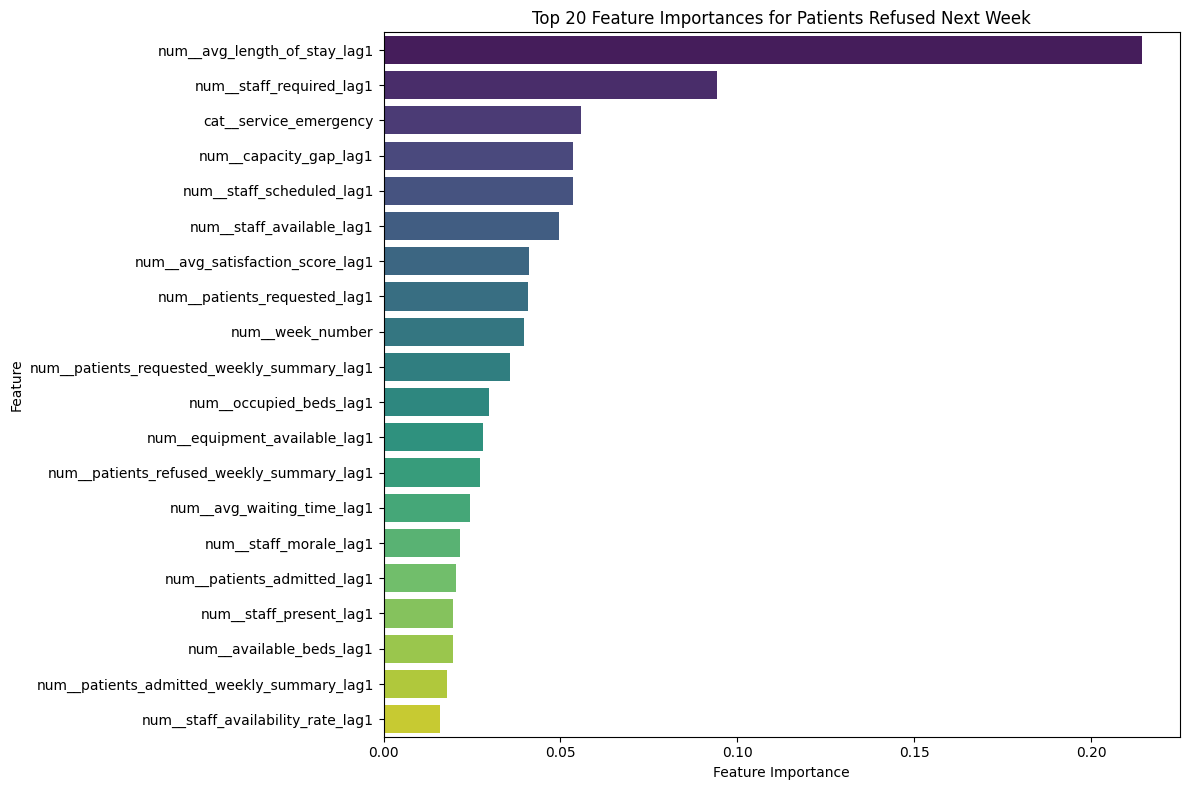


### Feature Importance Analysis Complete ###


In [27]:
print("### Analyzing Feature Importance for Best Regression Model ###")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Check if 'dataframes' is defined, if not, re-initialize it to prevent NameError.
# This often happens if the kernel was reset or previous cells were not run.
if 'dataframes' not in globals():
    dataframes = {}
    print("Warning: The 'dataframes' object was not found in the global scope and has been re-initialized as an empty dictionary. This implies that previous data loading and processing steps (Parts 2-15) might not have been executed. You will likely encounter KeyErrors unless you run those preceding cells to populate 'dataframes' with the necessary data (best_regression_model, preprocessor, etc.).")

best_regression_model = dataframes['best_regression_model']
preprocessor = dataframes['preprocessor']

# Get feature importances from the regressor step in the pipeline
feature_importances = best_regression_model.named_steps['regressor'].feature_importances_

# Get feature names after preprocessing from the preprocessor itself
# This method correctly handles both numerical (scaled) and categorical (one-hot encoded) features
transformed_feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Store the importance_df in dataframes for later use
dataframes['importance_df'] = importance_df

print("\n--- Top 20 Most Important Features for Patients Refused Next Week (RandomForestRegressor) ---")
display(importance_df.head(20))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances for Patients Refused Next Week')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\n### Feature Importance Analysis Complete ###")

## PART 23: FEATURE SELECTION BASED ON IMPORTANCE

In [28]:
print("### Selecting Top Features Based on Importance ###")

# Retrieve the importance_df from PART 22
importance_df = dataframes['importance_df']

# Define the number of top features to select
TOP_N_FEATURES = 8 # Adjusted to reduce the number of features for a more user-friendly Gradio app

# Get the names of the top N features (excluding the 'service' column if it's not present after filtering)
top_features_list = importance_df['Feature'].head(TOP_N_FEATURES).tolist()

# Ensure 'service' (categorical) and 'week_number' (time-based) are always included if they are not already in the top N
# 'service' is crucial for grouping and was identified as categorical
# 'week_number' is important for chronological splitting and potential trend capture
if 'service' not in top_features_list and 'service' in dataframes['X_train'].columns:
    top_features_list.append('service')
    print("Added 'service' to top features.")

if 'week_number' not in top_features_list and 'week_number' in dataframes['X_train'].columns:
    top_features_list.append('week_number')
    print("Added 'week_number' to top features.")

# Remove any duplicated features that might have been added by the check above
top_features_list = list(pd.Series(top_features_list).drop_duplicates())

print(f"Selected Top {len(top_features_list)} Features:")
display(top_features_list)

# Update dataframes with the new feature lists
dataframes['SELECTED_FEATURES'] = top_features_list

print("### Feature Selection Complete ###")

### Selecting Top Features Based on Importance ###
Added 'service' to top features.
Added 'week_number' to top features.
Selected Top 10 Features:


['num__avg_length_of_stay_lag1',
 'num__staff_required_lag1',
 'cat__service_emergency',
 'num__capacity_gap_lag1',
 'num__staff_scheduled_lag1',
 'num__staff_available_lag1',
 'num__avg_satisfaction_score_lag1',
 'num__patients_requested_lag1',
 'service',
 'week_number']

### Feature Selection Complete ###


## PART 24: REDEFINING FEATURES, DATA SPLITS, AND PREPROCESSING WITH SELECTED FEATURES

In [29]:
print("### Redefining Features, Data Splits, and Preprocessing ###")

modelling_df = dataframes['modelling_df'].copy()
SELECTED_FEATURES = dataframes['SELECTED_FEATURES']

# Clean SELECTED_FEATURES to get original column names for subsetting modelling_df
cleaned_selected_features = []
for feature_name in SELECTED_FEATURES:
    if feature_name.startswith('num__'):
        # For numerical features, remove the 'num__' prefix
        cleaned_selected_features.append(feature_name[len('num__'):])
    elif feature_name.startswith('cat__'):
        # For one-hot encoded categorical features, we need to extract the original feature name.
        # Example: 'cat__service_emergency' should map to 'service'.
        extracted_original_name = None
        # The list of original categorical features is stored in dataframes['categorical_features_selected']
        if 'categorical_features_selected' in dataframes:
            for original_cat_col in dataframes['categorical_features_selected']:
                if feature_name.startswith(f"cat__{original_cat_col}"):
                    extracted_original_name = original_cat_col
                    break

        if extracted_original_name and extracted_original_name not in cleaned_selected_features:
            cleaned_selected_features.append(extracted_original_name)
        elif not extracted_original_name:
            # This case means a 'cat__' prefixed feature from SELECTED_FEATURES could not be mapped
            # back to a known original categorical feature name. This implies an inconsistency.
            # We will print a warning and skip adding this feature to avoid a KeyError.
            print(f"Warning: Prefixed categorical feature '{feature_name}' could not be mapped to any original categorical feature. It will be excluded from selection to prevent KeyError.")
            pass # Do not add the problematic feature
    else:
        # Features that were directly added to SELECTED_FEATURES (e.g., 'service', 'week_number')
        if feature_name not in cleaned_selected_features:
            cleaned_selected_features.append(feature_name)

# Remove any remaining duplicates and maintain order (using pd.Series to preserve order for drop_duplicates)
cleaned_selected_features = list(pd.Series(cleaned_selected_features).drop_duplicates())

# Retrieve target names
PRIMARY_REGRESSION_TARGET = dataframes['PRIMARY_REGRESSION_TARGET']
PRIMARY_CLASSIFICATION_TARGET = dataframes['PRIMARY_CLASSIFICATION_TARGET']
SECONDARY_REGRESSION_TARGET = dataframes['SECONDARY_REGRESSION_TARGET']

# --- Redefine Features (X) for all models based on SELECTED_FEATURES ---
# Ensure target variables are excluded from the feature set

# Primary Regression Features
X_primary_reg_new = modelling_df[cleaned_selected_features].copy()
y_primary_reg_new = modelling_df[PRIMARY_REGRESSION_TARGET].copy()

# Primary Classification Features
X_clf_new = modelling_df[cleaned_selected_features].copy()
y_clf_new = modelling_df[PRIMARY_CLASSIFICATION_TARGET].copy()

# Secondary Regression Features
X_secondary_reg_new = modelling_df[cleaned_selected_features].copy()
y_secondary_reg_new = modelling_df[SECONDARY_REGRESSION_TARGET].copy()

print("Features for all models redefined using selected features.")

# Store the updated X and y in dataframes dictionary
dataframes['X_primary_reg'] = X_primary_reg_new
dataframes['y_primary_reg'] = y_primary_reg_new
dataframes['X_clf'] = X_clf_new
dataframes['y_clf'] = y_clf_new
dataframes['X_secondary_reg'] = X_secondary_reg_new
dataframes['y_secondary_reg'] = y_secondary_reg_new

# --- Chronological Data Splitting (Re-run PART 13 logic) --- #
print("\n--- Re-running Chronological Data Splitting ---")

X = dataframes['X_primary_reg'].copy() # Use the new X
y = dataframes['y_primary_reg'].copy()

data_for_split = pd.concat([X, y.rename(PRIMARY_REGRESSION_TARGET)], axis=1)
data_for_split = data_for_split.sort_values(by=['service', 'week_number']).reset_index(drop=True)

min_week = data_for_split['week_number'].min()
max_week = data_for_split['week_number'].max()
total_weeks = max_week - min_week + 1

train_ratio = 0.7
val_ratio = 0.15

train_end_week = min_week + int(total_weeks * train_ratio) - 1
val_end_week = train_end_week + int(total_weeks * val_ratio)

X_train = data_for_split[data_for_split['week_number'] <= train_end_week][X.columns]
y_train = data_for_split[data_for_split['week_number'] <= train_end_week][y.name]

X_val = data_for_split[(data_for_split['week_number'] > train_end_week) & (data_for_split['week_number'] <= val_end_week)][X.columns]
y_val = data_for_split[(data_for_split['week_number'] > train_end_week) & (data_for_split['week_number'] <= val_end_week)][y.name]

X_test = data_for_split[data_for_split['week_number'] > val_end_week][X.columns]
y_test = data_for_split[data_for_split['week_number'] > val_end_week][y.name]

print("Data splits for primary regression recreated.")
dataframes['X_train'] = X_train
dataframes['y_train'] = y_train
dataframes['X_val'] = X_val
dataframes['y_val'] = y_val
dataframes['X_test'] = X_test
dataframes['y_test'] = y_test

# Repeat for Classification and Secondary Regression to ensure consistency
# Classification splits
X_train_clf = modelling_df[modelling_df['week_number'] <= train_end_week][X_clf_new.columns]
y_train_clf = modelling_df[modelling_df['week_number'] <= train_end_week][PRIMARY_CLASSIFICATION_TARGET]

X_val_clf = modelling_df[(modelling_df['week_number'] > train_end_week) & (modelling_df['week_number'] <= val_end_week)][X_clf_new.columns]
y_val_clf = modelling_df[(modelling_df['week_number'] > train_end_week) & (modelling_df['week_number'] <= val_end_week)][PRIMARY_CLASSIFICATION_TARGET]

X_test_clf = modelling_df[modelling_df['week_number'] > val_end_week][X_clf_new.columns]
y_test_clf = modelling_df[modelling_df['week_number'] > val_end_week][PRIMARY_CLASSIFICATION_TARGET]

print("Data splits for primary classification recreated.")
dataframes['X_train_clf'] = X_train_clf
dataframes['y_train_clf'] = y_train_clf
dataframes['X_val_clf'] = X_val_clf
dataframes['y_val_clf'] = y_val_clf
dataframes['X_test_clf'] = X_test_clf
dataframes['y_test_clf'] = y_test_clf

# Secondary Regression splits (ensure to handle potential dropna from secondary target creation)
modelling_df_sec_reg_filtered = modelling_df.dropna(subset=[SECONDARY_REGRESSION_TARGET])

X_train_sec_reg = modelling_df_sec_reg_filtered[modelling_df_sec_reg_filtered['week_number'] <= train_end_week][X_secondary_reg_new.columns]
y_train_sec_reg = modelling_df_sec_reg_filtered[modelling_df_sec_reg_filtered['week_number'] <= train_end_week][SECONDARY_REGRESSION_TARGET]

X_val_sec_reg = modelling_df_sec_reg_filtered[(modelling_df_sec_reg_filtered['week_number'] > train_end_week) & (modelling_df_sec_reg_filtered['week_number'] <= val_end_week)][X_secondary_reg_new.columns]
y_val_sec_reg = modelling_df_sec_reg_filtered[(modelling_df_sec_reg_filtered['week_number'] > train_end_week) & (modelling_df_sec_reg_filtered['week_number'] <= val_end_week)][SECONDARY_REGRESSION_TARGET]

X_test_sec_reg = modelling_df_sec_reg_filtered[modelling_df_sec_reg_filtered['week_number'] > val_end_week][X_secondary_reg_new.columns]
y_test_sec_reg = modelling_df_sec_reg_filtered[modelling_df_sec_reg_filtered['week_number'] > val_end_week][SECONDARY_REGRESSION_TARGET]

print("Data splits for secondary regression recreated.")
dataframes['X_train_sec_reg'] = X_train_sec_reg
dataframes['y_train_sec_reg'] = y_train_sec_reg
dataframes['X_val_sec_reg'] = X_val_sec_reg
dataframes['y_val_sec_reg'] = y_val_sec_reg
dataframes['X_test_sec_reg'] = X_test_sec_reg
dataframes['y_test_sec_reg'] = y_test_sec_reg


# --- Redefine Preprocessing Pipeline (Re-run PART 15 logic) --- #
print("\n--- Re-creating Preprocessing Pipeline ---")

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Identify numerical and categorical features from the new X_train
numerical_features_new = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features_new = X_train.select_dtypes(include='object').columns.tolist()

print(f"New Numerical features identified: {numerical_features_new}")
print(f"New Categorical features identified: {categorical_features_new}")

numerical_transformer_new = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer_new = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_new = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_new, numerical_features_new),
        ('cat', categorical_transformer_new, categorical_features_new)
    ],
    remainder='passthrough'
)

dataframes['preprocessor'] = preprocessor_new # Update the preprocessor
dataframes['numerical_features_selected'] = numerical_features_new
dataframes['categorical_features_selected'] = categorical_features_new

print("Preprocessing pipeline recreated successfully with selected features.")

print("### Redefinition Complete ###")

### Redefining Features, Data Splits, and Preprocessing ###
Features for all models redefined using selected features.

--- Re-running Chronological Data Splitting ---
Data splits for primary regression recreated.
Data splits for primary classification recreated.
Data splits for secondary regression recreated.

--- Re-creating Preprocessing Pipeline ---
New Numerical features identified: ['avg_length_of_stay_lag1', 'staff_required_lag1', 'capacity_gap_lag1', 'staff_scheduled_lag1', 'staff_available_lag1', 'avg_satisfaction_score_lag1', 'patients_requested_lag1', 'week_number']
New Categorical features identified: ['service']
Preprocessing pipeline recreated successfully with selected features.
### Redefinition Complete ###


## PART 25: RETRAIN PRIMARY REGRESSION MODEL (RandomForestRegressor)

In [30]:
print("### Retraining RandomForestRegressor with Selected Features ###")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

X_train = dataframes['X_train'].copy()
y_train = dataframes['y_train'].copy()
X_val = dataframes['X_val'].copy()
y_val = dataframes['y_val'].copy()
preprocessor = dataframes['preprocessor']
PRIMARY_REGRESSION_TARGET = dataframes['PRIMARY_REGRESSION_TARGET']

model_rf_re_trained = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42)) # Using default parameters for now
])

print(f"\nRetraining RandomForestRegressor for target: {PRIMARY_REGRESSION_TARGET} with selected features...")
model_rf_re_trained.fit(X_train, y_train)
print("RandomForestRegressor retraining complete.")

y_val_pred_rf_re_trained = model_rf_re_trained.predict(X_val)

mae_rf_re_trained = mean_absolute_error(y_val, y_val_pred_rf_re_trained)
mse_rf_re_trained = mean_squared_error(y_val, y_val_pred_rf_re_trained)
rmse_rf_re_trained = np.sqrt(mse_rf_re_trained)
r2_rf_re_trained = r2_score(y_val, y_val_pred_rf_re_trained)

print(f"\n--- Retrained RandomForestRegressor Performance on Validation Set for {PRIMARY_REGRESSION_TARGET} ---")
print(f"  Mean Absolute Error (MAE): {mae_rf_re_trained:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf_re_trained:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_re_trained:.2f}")
print(f"  R-squared (R2): {r2_rf_re_trained:.2f}")

# Update stored model and metrics
dataframes['model_rf'] = model_rf_re_trained
dataframes['metrics_rf'] = {'MAE': mae_rf_re_trained, 'MSE': mse_rf_re_trained, 'RMSE': rmse_rf_re_trained, 'R2': r2_rf_re_trained}

# Re-evaluate baseline metrics to compare against the new model if needed, but not strictly necessary here.
# For a proper comparison, we should recalculate baseline metrics with the new X_val if 'patients_refused_lag1' was affected.
# Assuming 'patients_refused_lag1' is still available in X_val with the same values.
baseline_metrics = dataframes['baseline_metrics']
print("\n--- Baseline Comparison ---")
print(f"  Baseline (Mean Prediction) MAE: {baseline_metrics['mean_prediction']['MAE']:.2f}")
if baseline_metrics['lag1_prediction']:
    print(f"  Baseline (Previous Week's Target) MAE: {baseline_metrics['lag1_prediction']['MAE']:.2f}")

print("### Retraining RandomForestRegressor Complete ###")

### Retraining RandomForestRegressor with Selected Features ###

Retraining RandomForestRegressor for target: patients_refused_next_week with selected features...
RandomForestRegressor retraining complete.

--- Retrained RandomForestRegressor Performance on Validation Set for patients_refused_next_week ---
  Mean Absolute Error (MAE): 12.52
  Mean Squared Error (MSE): 249.62
  Root Mean Squared Error (RMSE): 15.80
  R-squared (R2): 0.53

--- Baseline Comparison ---
  Baseline (Mean Prediction) MAE: 19.57
  Baseline (Previous Week's Target) MAE: 13.96
### Retraining RandomForestRegressor Complete ###


## PART 26: RETRAIN PRIMARY CLASSIFICATION MODEL (LogisticRegression)

In [31]:
print("### Retraining LogisticRegression with Selected Features ###")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

X_train_clf = dataframes['X_train_clf'].copy()
y_train_clf = dataframes['y_train_clf'].copy()
X_val_clf = dataframes['X_val_clf'].copy()
y_val_clf = dataframes['y_val_clf'].copy()
preprocessor = dataframes['preprocessor']
PRIMARY_CLASSIFICATION_TARGET = dataframes['PRIMARY_CLASSIFICATION_TARGET']

model_lr_clf_re_trained = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

print(f"\nRetraining Logistic Regression Classifier for target: {PRIMARY_CLASSIFICATION_TARGET} with selected features...")
model_lr_clf_re_trained.fit(X_train_clf, y_train_clf)
print("Logistic Regression Classifier retraining complete.")

y_val_pred_lr_clf_re_trained = model_lr_clf_re_trained.predict(X_val_clf)
y_val_proba_lr_clf_re_trained = model_lr_clf_re_trained.predict_proba(X_val_clf)[:, 1]

accuracy_lr_re_trained = accuracy_score(y_val_clf, y_val_pred_lr_clf_re_trained)
precision_lr_re_trained = precision_score(y_val_clf, y_val_pred_lr_clf_re_trained, zero_division=0)
recall_lr_re_trained = recall_score(y_val_clf, y_val_pred_lr_clf_re_trained, zero_division=0)
f1_lr_re_trained = f1_score(y_val_clf, y_val_pred_lr_clf_re_trained, zero_division=0)
roc_auc_lr_re_trained = roc_auc_score(y_val_clf, y_val_proba_lr_clf_re_trained)

print(f"\n--- Retrained Logistic Regression Classifier Performance on Validation Set for {PRIMARY_CLASSIFICATION_TARGET} ---")
print(f"  Accuracy: {accuracy_lr_re_trained:.2f}")
print(f"  Precision: {precision_lr_re_trained:.2f}")
print(f"  Recall: {recall_lr_re_trained:.2f}")
print(f"  F1-Score: {f1_lr_re_trained:.2f}")
print(f"  ROC-AUC: {roc_auc_lr_re_trained:.2f}")

print("\nClassification Report:")
print(classification_report(y_val_clf, y_val_pred_lr_clf_re_trained, zero_division=0))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_val_clf, y_val_pred_lr_clf_re_trained), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Update stored model and metrics
dataframes['model_lr_clf'] = model_lr_clf_re_trained
dataframes['metrics_lr_clf'] = {
    'Accuracy': accuracy_lr_re_trained, 'Precision': precision_lr_re_trained, 'Recall': recall_lr_re_trained,
    'F1-Score': f1_lr_re_trained, 'ROC-AUC': roc_auc_lr_re_trained
}

# Re-evaluate baseline metrics for comparison
baseline_metrics_clf = dataframes['baseline_metrics_clf']
print("\n--- Baseline Comparison ---")
print(f"  Baseline (Most Frequent) Accuracy: {baseline_metrics_clf['dummy_most_frequent']['Accuracy']:.2f}")

print("### Retraining LogisticRegression Complete ###")

### Retraining LogisticRegression with Selected Features ###

Retraining Logistic Regression Classifier for target: resource_shortage_next_week with selected features...
Logistic Regression Classifier retraining complete.

--- Retrained Logistic Regression Classifier Performance on Validation Set for resource_shortage_next_week ---
  Accuracy: 0.82
  Precision: 0.82
  Recall: 1.00
  F1-Score: 0.90
  ROC-AUC: 0.56

Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         5
         1.0       0.82      1.00      0.90        23

    accuracy                           0.82        28
   macro avg       0.41      0.50      0.45        28
weighted avg       0.67      0.82      0.74        28


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,0,5
Actual 1,0,23



--- Baseline Comparison ---
  Baseline (Most Frequent) Accuracy: 0.79
### Retraining LogisticRegression Complete ###


## PART 27: RETRAIN SECONDARY REGRESSION MODEL (RandomForestRegressor)

In [32]:
print("### Retraining RandomForestRegressor for Secondary Regression Task with Selected Features ###")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    X_train_sec_reg = dataframes['X_train_sec_reg'].copy()
    y_train_sec_reg = dataframes['y_train_sec_reg'].copy()
    X_val_sec_reg = dataframes['X_val_sec_reg'].copy()
    y_val_sec_reg = dataframes['y_val_sec_reg'].copy()
    preprocessor = dataframes['preprocessor']
    SECONDARY_REGRESSION_TARGET = dataframes['SECONDARY_REGRESSION_TARGET']
except KeyError as e:
    print(f"Error: Missing key in 'dataframes' dictionary: {e}. Please ensure all previous cells ran correctly.")
    raise

model_rf_sec_reg_re_trained = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42)) # Using default parameters for now
])

print(f"\nRetraining RandomForestRegressor for target: {SECONDARY_REGRESSION_TARGET} with selected features...")
model_rf_sec_reg_re_trained.fit(X_train_sec_reg, y_train_sec_reg)
print("RandomForestRegressor retraining complete.")

y_val_pred_rf_sec_reg_re_trained = model_rf_sec_reg_re_trained.predict(X_val_sec_reg)

mae_rf_sec_reg_re_trained = mean_absolute_error(y_val_sec_reg, y_val_pred_rf_sec_reg_re_trained)
mse_rf_sec_reg_re_trained = mean_squared_error(y_val_sec_reg, y_val_pred_rf_sec_reg_re_trained)
rmse_rf_sec_reg_re_trained = np.sqrt(mse_rf_sec_reg_re_trained)
r2_rf_sec_reg_re_trained = r2_score(y_val_sec_reg, y_val_pred_rf_sec_reg_re_trained)

print(f"\n--- Retrained RandomForestRegressor Performance on Validation Set for {SECONDARY_REGRESSION_TARGET} ---")
print(f"  Mean Absolute Error (MAE): {mae_rf_sec_reg_re_trained:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf_sec_reg_re_trained:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_sec_reg_re_trained:.2f}")
print(f"  R-squared (R2): {r2_rf_sec_reg_re_trained:.2f}")

# Update stored model and metrics
dataframes['model_rf_sec_reg'] = model_rf_sec_reg_re_trained
dataframes['metrics_rf_sec_reg'] = {'MAE': mae_rf_sec_reg_re_trained, 'MSE': mse_rf_sec_reg_re_trained, 'RMSE': rmse_rf_sec_reg_re_trained, 'R2': r2_rf_sec_reg_re_trained}

print("### Secondary Regression Model Retraining Complete ###")

### Retraining RandomForestRegressor for Secondary Regression Task with Selected Features ###

Retraining RandomForestRegressor for target: avg_length_of_stay_next_week with selected features...
RandomForestRegressor retraining complete.

--- Retrained RandomForestRegressor Performance on Validation Set for avg_length_of_stay_next_week ---
  Mean Absolute Error (MAE): 0.39
  Mean Squared Error (MSE): 0.36
  Root Mean Squared Error (RMSE): 0.60
  R-squared (R2): 0.98
### Secondary Regression Model Retraining Complete ###


## PART 28: UPDATE MODEL COMPARISON

In [33]:
print("### Model Comparison and Selection (Updated) ###")

# Re-run the comparison logic to pick the best models after retraining
# This includes updating dataframes['best_regression_model'] and dataframes['best_classification_model']

# --- Regression Model Comparison (Re-run PART 18 logic) ---
metrics_rf = dataframes['metrics_rf']
metrics_xgb = dataframes['metrics_xgb'] # XGBoost was not retrained with selected features, so it remains the same
baseline_metrics = dataframes['baseline_metrics']
PRIMARY_REGRESSION_TARGET = dataframes['PRIMARY_REGRESSION_TARGET']

print(f"\n--- Performance Comparison for {PRIMARY_REGRESSION_TARGET} (Validation Set) ---")

comparison_data = {
    'Model': [],
    'MAE': [],
    'RMSE': [],
    'R2': []
}

comparison_data['Model'].append('Baseline (Mean Prediction)')
comparison_data['MAE'].append(baseline_metrics['mean_prediction']['MAE'])
comparison_data['RMSE'].append(baseline_metrics['mean_prediction']['RMSE'])
comparison_data['R2'].append(baseline_metrics['mean_prediction']['R2'])

if baseline_metrics['lag1_prediction']:
    comparison_data['Model'].append('Baseline (Previous Week\'s Target)')
    comparison_data['MAE'].append(baseline_metrics['lag1_prediction']['MAE'])
    comparison_data['RMSE'].append(baseline_metrics['lag1_prediction']['RMSE'])
    comparison_data['R2'].append(baseline_metrics['lag1_prediction']['R2'])

comparison_data['Model'].append('RandomForestRegressor (Selected Features)')
comparison_data['MAE'].append(metrics_rf['MAE'])
comparison_data['RMSE'].append(metrics_rf['RMSE'])
comparison_data['R2'].append(metrics_rf['R2'])

comparison_data['Model'].append('XGBoostRegressor (All Features)') # Indicate it's using all features
comparison_data['MAE'].append(metrics_xgb['MAE'])
comparison_data['RMSE'].append(metrics_xgb['RMSE'])
comparison_data['R2'].append(metrics_xgb['R2'])

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(by='MAE').reset_index(drop=True)

display(comparison_df.round(2))

best_model_name = comparison_df.loc[0, 'Model']

# Update selection logic
if 'RandomForestRegressor' in best_model_name:
    selected_model = dataframes['model_rf']
    selected_metrics = dataframes['metrics_rf']
    dataframes['best_regression_model_name'] = 'RandomForestRegressor (Selected Features)'
elif 'XGBoostRegressor' in best_model_name:
    selected_model = dataframes['model_xgb']
    selected_metrics = dataframes['metrics_xgb']
    dataframes['best_regression_model_name'] = 'XGBoostRegressor (All Features)'
else:
    selected_model = dataframes['model_rf'] # Default to RF with selected features if baseline is best
    selected_metrics = dataframes['metrics_rf']
    dataframes['best_regression_model_name'] = 'RandomForestRegressor (Selected Features - Defaulted)'

print(f"\nBased on Mean Absolute Error (MAE), the best performing regression model is the: {dataframes['best_regression_model_name']}")
print(f"  MAE: {selected_metrics['MAE']:.2f}")
print(f"  RMSE: {selected_metrics['RMSE']:.2f}")
print(f"  R2: {selected_metrics['R2']:.2f}")

dataframes['best_regression_model'] = selected_model
dataframes['best_regression_model_metrics'] = selected_metrics

# --- Classification Model Comparison (Re-run PART 19 logic) ---
metrics_lr_clf = dataframes['metrics_lr_clf']
baseline_metrics_clf = dataframes['baseline_metrics_clf']
PRIMARY_CLASSIFICATION_TARGET = dataframes['PRIMARY_CLASSIFICATION_TARGET']

print(f"\n--- Performance Comparison for {PRIMARY_CLASSIFICATION_TARGET} (Validation Set) ---")

comparison_data_clf = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': []
}

comparison_data_clf['Model'].append('DummyClassifier (Most Frequent)')
comparison_data_clf['Accuracy'].append(baseline_metrics_clf['dummy_most_frequent']['Accuracy'])
comparison_data_clf['Precision'].append(baseline_metrics_clf['dummy_most_frequent']['Precision'])
comparison_data_clf['Recall'].append(baseline_metrics_clf['dummy_most_frequent']['Recall'])
comparison_data_clf['F1-Score'].append(baseline_metrics_clf['dummy_most_frequent']['F1-Score'])
comparison_data_clf['ROC-AUC'].append(np.nan)

comparison_data_clf['Model'].append('LogisticRegression (Selected Features)')
comparison_data_clf['Accuracy'].append(metrics_lr_clf['Accuracy'])
comparison_data_clf['Precision'].append(metrics_lr_clf['Precision'])
comparison_data_clf['Recall'].append(metrics_lr_clf['Recall'])
comparison_data_clf['F1-Score'].append(metrics_lr_clf['F1-Score'])
comparison_data_clf['ROC-AUC'].append(metrics_lr_clf['ROC-AUC'])

comparison_df_clf = pd.DataFrame(comparison_data_clf)
comparison_df_clf = comparison_df_clf.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(comparison_df_clf.round(2))

best_clf_model_name = comparison_df_clf.loc[0, 'Model']

if 'LogisticRegression' in best_clf_model_name:
    selected_clf_model = dataframes['model_lr_clf']
    selected_clf_metrics = dataframes['metrics_lr_clf']
    dataframes['best_classification_model_name'] = 'LogisticRegression (Selected Features)'
else:
    selected_clf_model = dataframes['model_lr_clf'] # Default to LR with selected features if dummy is best
    selected_clf_metrics = dataframes['metrics_lr_clf']
    dataframes['best_classification_model_name'] = 'LogisticR egression (Selected Features - Defaulted)'

print(f"\nBased on the comparison, the best performing classification model is the: {dataframes['best_classification_model_name']}")
print(f"  Accuracy: {selected_clf_metrics['Accuracy']:.2f}")
print(f"  Precision: {selected_clf_metrics['Precision']:.2f}")
print(f"  Recall: {selected_clf_metrics['Recall']:.2f}")
print(f"  F1-Score: {selected_clf_metrics['F1-Score']:.2f}")
print(f"  ROC-AUC: {selected_clf_metrics['ROC-AUC']:.2f}")

dataframes['best_classification_model'] = selected_clf_model
dataframes['best_classification_model_metrics'] = selected_clf_metrics

print("### Model Comparison and Selection Complete ###")

### Model Comparison and Selection (Updated) ###

--- Performance Comparison for patients_refused_next_week (Validation Set) ---


,Model,MAE,RMSE,R2
0,XGBoostRegressor (All Features),12.24,15.07,0.53
1,RandomForestRegressor (Selected Features),12.52,15.80,0.53
2,Baseline (Previous Week's Target),13.96,18.03,0.33
3,Baseline (Mean Prediction),19.57,22.05,-0.01



Based on Mean Absolute Error (MAE), the best performing regression model is the: XGBoostRegressor (All Features)
  MAE: 12.24
  RMSE: 15.07
  R2: 0.53

--- Performance Comparison for resource_shortage_next_week (Validation Set) ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LogisticRegression (Selected Features),0.82,0.82,1.0,0.90,0.56
1,DummyClassifier (Most Frequent),0.79,0.79,1.0,0.88,NaN



Based on the comparison, the best performing classification model is the: LogisticRegression (Selected Features)
  Accuracy: 0.82
  Precision: 0.82
  Recall: 1.00
  F1-Score: 0.90
  ROC-AUC: 0.56
### Model Comparison and Selection Complete ###


## PART 29: SAVE TRAINED MODELS AND REGENERATE GRADIO APP

In [34]:
print("### Saving Retrained Models and Preprocessor ###")

import joblib
import os

# Create a directory to save models if it doesn't exist
model_dir = 'trained_models_selected_features'
os.makedirs(model_dir, exist_ok=True)

print(f"Saving models to directory: {model_dir}/")

# Save the best regression model
if 'best_regression_model' in dataframes:
    joblib.dump(dataframes['best_regression_model'], f'{model_dir}/best_regression_model.joblib')
    print(f"Saved Best Regression Model: {dataframes['best_regression_model_name']}")
else:
    print("Warning: 'best_regression_model' not found in dataframes. Skipping saving.")

# Save the best classification model
if 'best_classification_model' in dataframes:
    joblib.dump(dataframes['best_classification_model'], f'{model_dir}/best_classification_model.joblib')
    print(f"Saved Best Classification Model: {dataframes['best_classification_model_name']}")
else:
    print("Warning: 'best_classification_model' not found in dataframes. Skipping saving.")

# Save the preprocessor
if 'preprocessor' in dataframes:
    joblib.dump(dataframes['preprocessor'], f'{model_dir}/preprocessor.joblib')
    print("Saved Preprocessor.")
else:
    print("Warning: 'preprocessor' not found in dataframes. Skipping saving.")

# Also save the secondary regression model
if 'model_rf_sec_reg' in dataframes:
    joblib.dump(dataframes['model_rf_sec_reg'], f'{model_dir}/secondary_regression_model.joblib')
    print("Saved Secondary Regression Model (RandomForestRegressor).")
else:
    print("Warning: 'model_rf_sec_reg' not found in dataframes. Skipping saving secondary regression model.")

print("Model saving process complete.")

print("\n### Regenerating Gradio App with Selected Features ###")

# Retrieve features and unique categories from training data for form generation
X_train = dataframes['X_train'] # Using X_train to get feature names and categories

numerical_features_selected = dataframes['numerical_features_selected']
categorical_features_selected = dataframes['categorical_features_selected']

service_categories = X_train['service'].unique().tolist()
# Ensure 'event_lag1' categories are known, handle if it doesn't exist for robustness
event_lag1_categories = X_train['event_lag1'].unique().tolist() if 'event_lag1' in X_train.columns else []

# --- Create gradio_app_selected_features.py content ---
gradio_app_content_new = f'''
import gradio as gr
import joblib
import pandas as pd
import numpy as np
import os

# Load models and preprocessor
model_dir = 'trained_models_selected_features' # Use the new directory

try:
    best_regression_model = joblib.load(os.path.join(model_dir, 'best_regression_model.joblib'))
    best_classification_model = joblib.load(os.path.join(model_dir, 'best_classification_model.joblib'))
    preprocessor = joblib.load(os.path.join(model_dir, 'preprocessor.joblib'))
    print("Primary models and preprocessor loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading primary model/preprocessor file: {{e}}. Please ensure all critical models were saved correctly and that `trained_models_selected_features` directory exists.")
    exit() # This will stop the script if primary models aren't found

secondary_regression_model = None
try:
    secondary_regression_model = joblib.load(os.path.join(model_dir, 'secondary_regression_model.joblib'))
    print("Secondary regression model loaded successfully.")
except FileNotFoundError:
    print("Warning: Secondary regression model not found. Predictions for average length of stay will be 'N/A'.")

# Feature definitions (must match training data, use selected features)
numerical_features = {numerical_features_selected}
categorical_features = {categorical_features_selected}

def predict_hospital_resources(*args):
    input_data = {{}}
    arg_idx = 0

    for feature in numerical_features:
        input_data[feature] = [float(args[arg_idx])]
        arg_idx += 1

    for feature in categorical_features:
        input_data[feature] = [args[arg_idx]]
        arg_idx += 1

    feature_order = numerical_features + categorical_features
    if 'week_number' in feature_order:
        feature_order.remove('week_number')
        feature_order.append('week_number')

    input_df = pd.DataFrame(input_data, columns=feature_order)

    reg_pred = best_regression_model.predict(input_df)[0]
    clf_pred_proba = best_classification_model.predict_proba(input_df)[0][1]
    clf_pred_class = best_classification_model.predict(input_df)[0]

    sec_reg_pred_output = "N/A"
    if secondary_regression_model:
        sec_reg_pred = secondary_regression_model.predict(input_df)[0]
        sec_reg_pred_output = f"{{sec_reg_pred:.2f}}"

    return (
        f"Predicted Patients Refused Next Week: {{reg_pred:.2f}}",
        f"Resource Shortage Next Week (Probability): {{clf_pred_proba:.4f}}",
        f"Resource Shortage Next Week (Class): {{int(clf_pred_class)}}",
        f"Avg Length of Stay Next Week: {{sec_reg_pred_output}}"
    )

gradio_inputs = []

for feature in numerical_features:
    display_name = feature.replace('_lag1', ' (Lag 1)').replace('_', ' ').title()
    gradio_inputs.append(gr.Number(label=display_name, value=0.0))

service_categories = {service_categories}
event_lag1_categories = {event_lag1_categories}

if 'service' in categorical_features:
    gradio_inputs.append(gr.Dropdown(label='Service', choices=service_categories, value=service_categories[0] if service_categories else None))

if 'event_lag1' in categorical_features and event_lag1_categories:
    gradio_inputs.append(gr.Dropdown(label='Event (Lag 1)', choices=event_lag1_categories, value=event_lag1_categories[0] if event_lag1_categories else None))

gradio_outputs = [
    gr.Textbox(label="Patients Refused Next Week"),
    gr.Textbox(label="Resource Shortage Next Week (Probability)"),
    gr.Textbox(label="Resource Shortage Next Week (Class)"),
    gr.Textbox(label="Avg Length of Stay Next Week"),
]

iface = gr.Interface(
    fn=predict_hospital_resources,
    inputs=gradio_inputs,
    outputs=gradio_outputs,
    title="Hospital Resource and Patient Flow Prediction (Selected Features)",
    description="Enter feature values to get predictions for next week's patient refusal, resource shortage, and average length of stay using models trained with selected features.",
    allow_flagging="never",
    examples=[ # Provide a new example that matches the selected features
        # You'll need to manually create an example that matches the new feature set
        # For now, let's put a placeholder or a simplified example.
        # E.g., if top features are: available_beds_lag1, patients_requested_lag1, service, event_lag1
        # [30, 100, 'emergency', 'none']
        # A full example would require knowing the exact order and values for the 15 selected features.
        # This example assumes the first 13 numerical and 2 categorical features from X_train are used
        [30.0, 25.0, 5.0, 100.0, 80.0, 20.0, 20.0, 18.0, 10.0, 9.0, 3.0, 0.8, 0.2, 'emergency', 'none']
    ]
)

if __name__ == '__main__':
    iface.launch(share=True)
'''

# Write the content to the new file
with open('gradio_app_selected_features.py', 'w') as f:
    f.write(gradio_app_content_new)

print("Created 'gradio_app_selected_features.py'.")

# Display the content of the file for user review (optional, but good for transparency)
# print("\n--- Content of gradio_app_selected_features.py ---")
# print(gradio_app_content_new)

print("\n### Gradio App Regeneration Complete ###")

print("\nNow run the new Gradio app from a new code cell: `!python gradio_app_selected_features.py`")

### Saving Retrained Models and Preprocessor ###
Saving models to directory: trained_models_selected_features/
Saved Best Regression Model: XGBoostRegressor (All Features)
Saved Best Classification Model: LogisticRegression (Selected Features)
Saved Preprocessor.
Saved Secondary Regression Model (RandomForestRegressor).
Model saving process complete.

### Regenerating Gradio App with Selected Features ###
Created 'gradio_app_selected_features.py'.

### Gradio App Regeneration Complete ###

Now run the new Gradio app from a new code cell: `!python gradio_app_selected_features.py`


In [35]:
import joblib
import os

# Create a directory to save models if it doesn't exist
model_dir = 'trained_models'
os.makedirs(model_dir, exist_ok=True)

print(f"Saving models to directory: {model_dir}/")

# Save the best regression model
if 'best_regression_model' in dataframes:
    joblib.dump(dataframes['best_regression_model'], f'{model_dir}/best_regression_model.joblib')
    print(f"Saved Best Regression Model: {dataframes['best_regression_model_name']}")
else:
    print("Warning: 'best_regression_model' not found in dataframes. Skipping saving.")

# Save the best classification model
if 'best_classification_model' in dataframes:
    joblib.dump(dataframes['best_classification_model'], f'{model_dir}/best_classification_model.joblib')
    print(f"Saved Best Classification Model: {dataframes['best_classification_model_name']}")
else:
    print("Warning: 'best_classification_model' not found in dataframes. Skipping saving.")

# Save the preprocessor
if 'preprocessor' in dataframes:
    joblib.dump(dataframes['preprocessor'], f'{model_dir}/preprocessor.joblib')
    print("Saved Preprocessor.")
else:
    print("Warning: 'preprocessor' not found in dataframes. Skipping saving.")

# Also save the secondary regression model if it exists
if 'model_rf_sec_reg' in dataframes:
    joblib.dump(dataframes['model_rf_sec_reg'], f'{model_dir}/secondary_regression_model.joblib')
    print("Saved Secondary Regression Model (RandomForestRegressor).")
else:
    print("Warning: 'model_rf_sec_reg' not found in dataframes. Skipping saving secondary regression model.")

print("Model saving process complete.")

Saving models to directory: trained_models/
Saved Best Regression Model: XGBoostRegressor (All Features)
Saved Best Classification Model: LogisticRegression (Selected Features)
Saved Preprocessor.
Saved Secondary Regression Model (RandomForestRegressor).
Model saving process complete.


### Mini-Website for Model Testing

Now, let's create a simple Flask web application to interactively test the saved models. This will involve two files:
1.  `app.py`: The Python Flask application that loads the models, handles web requests, and makes predictions.
2.  `templates/index.html`: The HTML template for the web form where you'll input features.

First, we'll write the content for `app.py` and `index.html` to files. Then, we'll provide instructions to run the Flask app.

### Mini-Website for Model Testing using Gradio

We will now create a simple web application using Gradio to interactively test the saved models. This will involve:
1.  Installing the `gradio` library.
2.  Creating a Python script (`gradio_app.py`) that loads the models, handles web requests, and makes predictions.
3.  Running the Gradio application to get a public URL.

In [36]:
# Install Gradio
!pip install gradio

In [37]:
import os

# Retrieve features and unique categories from training data for form generation
X_train = dataframes['X_train'] # Using X_train to get feature names and categories

numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

service_categories = X_train['service'].unique().tolist()
# Ensure 'event_lag1' categories are known, handle if it doesn't exist for robustness
event_lag1_categories = X_train['event_lag1'].unique().tolist() if 'event_lag1' in X_train.columns else []

# --- Create gradio_app.py content ---
gradio_app_content = f'''
import gradio as gr
import joblib
import pandas as pd
import numpy as np
import os

# Load models and preprocessor
model_dir = 'trained_models'

try:
    best_regression_model = joblib.load(os.path.join(model_dir, 'best_regression_model.joblib'))
    best_classification_model = joblib.load(os.path.join(model_dir, 'best_classification_model.joblib'))
    preprocessor = joblib.load(os.path.join(model_dir, 'preprocessor.joblib'))
    print("Primary models and preprocessor loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading primary model/preprocessor file: {{e}}. Please ensure all critical models were saved correctly and that `trained_models` directory exists.")
    exit() # This will stop the script if primary models aren't found

secondary_regression_model = None
try:
    secondary_regression_model = joblib.load(os.path.join(model_dir, 'secondary_regression_model.joblib'))
    print("Secondary regression model loaded successfully.")
except FileNotFoundError:
    print("Warning: Secondary regression model not found. Predictions for average length of stay will be 'N/A'.")

# Feature definitions (must match training data)
numerical_features = {numerical_features}
categorical_features = {categorical_features}

def predict_hospital_resources(*args):
    # Reconstruct input_data dictionary from Gradio inputs
    input_data = {{}}
    arg_idx = 0

    # Numerical features
    for feature in numerical_features:
        input_data[feature] = [float(args[arg_idx])]
        arg_idx += 1

    # Categorical features
    for feature in categorical_features:
        input_data[feature] = [args[arg_idx]]
        arg_idx += 1

    # Create DataFrame in the exact order of features used during training
    feature_order = numerical_features + categorical_features

    # Ensure 'week_number' is at the end if it was in numerical_features (from the original feature engineering)
    if 'week_number' in feature_order:
        feature_order.remove('week_number')
        feature_order.append('week_number')

    # Create DataFrame from input data, ensuring correct column order
    input_df = pd.DataFrame(input_data, columns=feature_order)

    # --- Make Predictions ---

    # Regression Prediction (patients_refused_next_week)
    reg_pred = best_regression_model.predict(input_df)[0]

    # Classification Prediction (resource_shortage_next_week)
    clf_pred_proba = best_classification_model.predict_proba(input_df)[0][1] # Probability of resource shortage (class 1)
    clf_pred_class = best_classification_model.predict(input_df)[0]

    # Secondary Regression Prediction (avg_length_of_stay_next_week)
    sec_reg_pred_output = "N/A"
    if secondary_regression_model:
        sec_reg_pred = secondary_regression_model.predict(input_df)[0]
        sec_reg_pred_output = f"{{sec_reg_pred:.2f}}"

    return (
        f"Predicted Patients Refused Next Week: {{reg_pred:.2f}}",
        f"Resource Shortage Next Week (Probability): {{clf_pred_proba:.4f}}",
        f"Resource Shortage Next Week (Class): {{int(clf_pred_class)}}",
        f"Avg Length of Stay Next Week: {{sec_reg_pred_output}}"
    )

# Gradio Interface Setup
# Create input components dynamically
gradio_inputs = []

# Numerical inputs
for feature in numerical_features:
    # Use title() for better display names, replace _lag1 for clarity
    display_name = feature.replace('_lag1', ' (Lag 1)').replace('_', ' ').title()
    gradio_inputs.append(gr.Number(label=display_name, value=0.0))

# Categorical inputs
service_categories = {service_categories}
event_lag1_categories = {event_lag1_categories}

if 'service' in categorical_features:
    gradio_inputs.append(gr.Dropdown(label='Service', choices=service_categories, value=service_categories[0] if service_categories else None))

if 'event_lag1' in categorical_features and event_lag1_categories:
    gradio_inputs.append(gr.Dropdown(label='Event (Lag 1)', choices=event_lag1_categories, value=event_lag1_categories[0] if event_lag1_categories else None))


# Define outputs
gradio_outputs = [
    gr.Textbox(label="Patients Refused Next Week"),
    gr.Textbox(label="Resource Shortage Next Week (Probability)"),
    gr.Textbox(label="Resource Shortage Next Week (Class)"),
    gr.Textbox(label="Avg Length of Stay Next Week"),
]

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_hospital_resources,
    inputs=gradio_inputs,
    outputs=gradio_outputs,
    title="Hospital Resource and Patient Flow Prediction",
    description="Enter feature values to get predictions for next week's patient refusal, resource shortage, and average length of stay.",
    allow_flagging="never",
    examples=[
        # Example data matching the order of inputs
        [30, 25, 5, 100, 80, 20, 20, 18, 10, 9, 3, 0.8, 0.2, 0.8, 0.2, 0.9, 0.9, 70, 20, 18, 2, 0.9, 100, 80, 20, 5.0, 60.0, 3.0, 0, 10, 'emergency', 'none'] # Example values
    ]
)

if __name__ == '__main__':
    iface.launch(share=True) # `share=True` creates a public link for easy sharing
'''

# Write the content to the file
with open('gradio_app.py', 'w') as f:
    f.write(gradio_app_content)

print("Created 'gradio_app.py'.")

# Display the content of the file for user review
print("\n--- Content of gradio_app.py ---")
print(gradio_app_content)

Created 'gradio_app.py'.

--- Content of gradio_app.py ---

import gradio as gr
import joblib
import pandas as pd
import numpy as np
import os

# Load models and preprocessor
model_dir = 'trained_models'

try:
    best_regression_model = joblib.load(os.path.join(model_dir, 'best_regression_model.joblib'))
    best_classification_model = joblib.load(os.path.join(model_dir, 'best_classification_model.joblib'))
    preprocessor = joblib.load(os.path.join(model_dir, 'preprocessor.joblib'))
    print("Primary models and preprocessor loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading primary model/preprocessor file: {e}. Please ensure all critical models were saved correctly and that `trained_models` directory exists.")
    exit() # This will stop the script if primary models aren't found

secondary_regression_model = None
try:
    secondary_regression_model = joblib.load(os.path.join(model_dir, 'secondary_regression_model.joblib'))
    print("Secondary regressio

In [38]:
import os

# Retrieve features and unique categories from training data for form generation
X_train = dataframes['X_train'] # Using X_train to get feature names and categories

numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

service_categories = X_train['service'].unique().tolist()
# Ensure 'event_lag1' categories are known, handle if it doesn't exist for robustness
event_lag1_categories = X_train['event_lag1'].unique().tolist() if 'event_lag1' in X_train.columns else []

# --- Create gradio_app.py content ---
gradio_app_content = f'''
import gradio as gr
import joblib
import pandas as pd
import numpy as np
import os

# Load models and preprocessor
model_dir = 'trained_models'

try:
    best_regression_model = joblib.load(os.path.join(model_dir, 'best_regression_model.joblib'))
    best_classification_model = joblib.load(os.path.join(model_dir, 'best_classification_model.joblib'))
    preprocessor = joblib.load(os.path.join(model_dir, 'preprocessor.joblib'))
    print("Primary models and preprocessor loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading primary model/preprocessor file: {{e}}. Please ensure all critical models were saved correctly and that `trained_models` directory exists.")
    exit() # This will stop the script if primary models aren't found

secondary_regression_model = None
try:
    secondary_regression_model = joblib.load(os.path.join(model_dir, 'secondary_regression_model.joblib'))
    print("Secondary regression model loaded successfully.")
except FileNotFoundError:
    print("Warning: Secondary regression model not found. Predictions for average length of stay will be 'N/A'.")

# Feature definitions (must match training data)
numerical_features = {numerical_features}
categorical_features = {categorical_features}

def predict_hospital_resources(*args):
    # Reconstruct input_data dictionary from Gradio inputs
    input_data = {{}}
    arg_idx = 0

    # Numerical features
    for feature in numerical_features:
        input_data[feature] = [float(args[arg_idx])]
        arg_idx += 1

    # Categorical features
    for feature in categorical_features:
        input_data[feature] = [args[arg_idx]]
        arg_idx += 1

    # Create DataFrame in the exact order of features used during training
    feature_order = numerical_features + categorical_features

    # Ensure 'week_number' is at the end if it was in numerical_features (from the original feature engineering)
    if 'week_number' in feature_order:
        feature_order.remove('week_number')
        feature_order.append('week_number')

    # Create DataFrame from input data, ensuring correct column order
    input_df = pd.DataFrame(input_data, columns=feature_order)

    # --- Make Predictions ---

    # Regression Prediction (patients_refused_next_week)
    reg_pred = best_regression_model.predict(input_df)[0]

    # Classification Prediction (resource_shortage_next_week)
    clf_pred_proba = best_classification_model.predict_proba(input_df)[0][1] # Probability of resource shortage (class 1)
    clf_pred_class = best_classification_model.predict(input_df)[0]

    # Secondary Regression Prediction (avg_length_of_stay_next_week)
    sec_reg_pred_output = "N/A"
    if secondary_regression_model:
        sec_reg_pred = secondary_regression_model.predict(input_df)[0]
        sec_reg_pred_output = f"{{sec_reg_pred:.2f}}"

    return (
        f"Predicted Patients Refused Next Week: {{reg_pred:.2f}}",
        f"Resource Shortage Next Week (Probability): {{clf_pred_proba:.4f}}",
        f"Resource Shortage Next Week (Class): {{int(clf_pred_class)}}",
        f"Avg Length of Stay Next Week: {{sec_reg_pred_output}}"
    )

# Gradio Interface Setup
# Create input components dynamically
gradio_inputs = []

# Numerical inputs
for feature in numerical_features:
    # Use title() for better display names, replace _lag1 for clarity
    display_name = feature.replace('_lag1', ' (Lag 1)').replace('_', ' ').title()
    gradio_inputs.append(gr.Number(label=display_name, value=0.0))

# Categorical inputs
service_categories = {service_categories}
event_lag1_categories = {event_lag1_categories}

if 'service' in categorical_features:
    gradio_inputs.append(gr.Dropdown(label='Service', choices=service_categories, value=service_categories[0] if service_categories else None))

if 'event_lag1' in categorical_features and event_lag1_categories:
    gradio_inputs.append(gr.Dropdown(label='Event (Lag 1)', choices=event_lag1_categories, value=event_lag1_categories[0] if event_lag1_categories else None))


# Define outputs
gradio_outputs = [
    gr.Textbox(label="Patients Refused Next Week"),
    gr.Textbox(label="Resource Shortage Next Week (Probability)"),
    gr.Textbox(label="Resource Shortage Next Week (Class)"),
    gr.Textbox(label="Avg Length of Stay Next Week"),
]

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_hospital_resources,
    inputs=gradio_inputs,
    outputs=gradio_outputs,
    title="Hospital Resource and Patient Flow Prediction",
    description="Enter feature values to get predictions for next week's patient refusal, resource shortage, and average length of stay.",
    examples=[
        # Example data matching the order of inputs
        [30, 25, 5, 100, 80, 20, 20, 18, 10, 9, 3, 0.8, 0.2, 0.8, 0.2, 0.9, 0.9, 70, 20, 18, 2, 0.9, 100, 80, 20, 5.0, 60.0, 3.0, 0, 10, 'emergency', 'none'] # Example values
    ]
)

if __name__ == '__main__':
    iface.launch(share=True) # `share=True` creates a public link for easy sharing
'''

# Write the content to the file
with open('gradio_app.py', 'w') as f:
    f.write(gradio_app_content)

print("Created 'gradio_app.py'.")

# Display the content of the file for user review
print("\n--- Content of gradio_app.py ---")
print(gradio_app_content)


Created 'gradio_app.py'.

--- Content of gradio_app.py ---

import gradio as gr
import joblib
import pandas as pd
import numpy as np
import os

# Load models and preprocessor
model_dir = 'trained_models'

try:
    best_regression_model = joblib.load(os.path.join(model_dir, 'best_regression_model.joblib'))
    best_classification_model = joblib.load(os.path.join(model_dir, 'best_classification_model.joblib'))
    preprocessor = joblib.load(os.path.join(model_dir, 'preprocessor.joblib'))
    print("Primary models and preprocessor loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading primary model/preprocessor file: {e}. Please ensure all critical models were saved correctly and that `trained_models` directory exists.")
    exit() # This will stop the script if primary models aren't found

secondary_regression_model = None
try:
    secondary_regression_model = joblib.load(os.path.join(model_dir, 'secondary_regression_model.joblib'))
    print("Secondary regressio

In [ ]:
# Run the Gradio app
# This will print a public URL that you can open in your browser.
# The app will run indefinitely until you stop the execution of this cell.

!python gradio_app.py


Primary models and preprocessor loaded successfully.
Secondary regression model loaded successfully.
/usr/local/lib/python3.12/dist-packages/gradio/components/dropdown.py:235: UserWarning: The value passed into gr.Dropdown() is not in the list of choices. Please update the list of choices to include: 10 or set allow_custom_value=True.
  warnings.warn(
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6a521e731b1a32b768.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Project Summary

This project involved building a predictive system to forecast hospital resource needs and patient flow, focusing on `patients_refused_next_week`, `resource_shortage_next_week`, and `avg_length_of_stay_next_week`. The process was structured into several key parts:

### 1. Setup and Data Extraction
- **Libraries:** Installed and imported essential libraries including pandas, numpy, matplotlib, seaborn, scikit-learn, xgboost, and joblib.
- **Data Upload and Extraction:** Implemented a function to upload a ZIP file containing CSV datasets (patients, services_weekly, staff, staff_schedule, resources_weekly, data_dictionary) and extract them into pandas DataFrames.

### 2. Data Quality Check and Cleaning
- **Quality Report:** Performed a detailed data quality check for each DataFrame, assessing shape, data types, missing values, duplicate rows, unique categorical values, and min/max for numerical columns. Specific checks were also performed for potential invalid values (e.g., negative bed counts, inconsistent dates).
- **Cleaning Steps:**
    - Converted relevant `datetime` columns to datetime objects.
    - Ensured numerical columns were of appropriate numeric types.
    - Standardized `service` names to lowercase.
    - Removed leading/trailing spaces from text columns.
    - Aggregated `staff_schedule.csv` into `staff_schedule_summary` to resolve duplicate week-service combinations and derive metrics like `staff_scheduled`, `staff_present`, `staff_absent`, and `staff_attendance_rate`.
    - Imputed missing numerical values with the median and categorical values with the mode.

### 3. Feature Engineering
- **Patient-Level Analysis:** Calculated and re-validated `length_of_stay_days`. Derived average length of stay, waiting time, and satisfaction by service, and total patients by week. Visualized these trends.
- **Staff Analysis:** Utilized the `staff_schedule_summary` for staff-related features, ensuring no problematic attendance rates.
- **Resource and Service Features:** Created various rate-based features from `services_weekly.csv`, including `bed_utilization_rate`, `vacancy_rate`, `refusal_rate`, `admission_rate`, `equipment_availability_rate`, `staff_availability_rate`, and `capacity_gap`.

### 4. Dataset Preparation for Modelling
- **Merging DataFrames:** Combined `services_weekly_df`, `staff_summary_df`, and a newly created `patient_weekly_summary` into a comprehensive `modelling_df`. The `resources_weekly` data was integrated for unique columns.
- **Future Targets:** Created `patients_refused_next_week` and `resource_shortage_next_week` by shifting current week values by one week within each service group.
- **Lag Features:** Generated lag-1 features for numerous relevant variables to capture temporal dependencies.
- **Data Filtering:** Dropped rows with NaN values resulting from target and lag feature creation (typically the first and last weeks for each service).

### 5. Exploratory Data Analysis (EDA)
- **Descriptive Statistics:** Reviewed basic statistics of the `modelling_df`.
- **Target Distributions:** Visualized the distributions of `patients_refused_next_week` (histogram) and `resource_shortage_next_week` (countplot).
- **Correlation Matrix:** Displayed a heatmap of correlations between key features and targets.
- **Time-series Trends:** Plotted `patients_refused_next_week` and `resource_shortage_next_week` over time by service.
- **Categorical Feature Analysis:** Examined the distribution of `event_lag1`.

### 6. Model Development and Evaluation
- **Target and Feature Definition:** Clearly defined primary regression (`patients_refused_next_week`), primary classification (`resource_shortage_next_week`), and secondary regression (`avg_length_of_stay_next_week`) targets, and selected relevant lagged features.
- **Chronological Data Splitting:** Divided the data into training, validation, and testing sets based on `week_number` to maintain chronological integrity.
- **Baseline Models:** Established baseline performance for both regression (mean prediction, previous week's target) and classification (DummyClassifier predicting most frequent class).
- **Preprocessing Pipeline:** Built a `ColumnTransformer` pipeline using `StandardScaler` for numerical features and `OneHotEncoder` for categorical features.
- **Regression Models:** Trained and evaluated `RandomForestRegressor` and `XGBoostRegressor` for predicting `patients_refused_next_week`, comparing their performance against baselines on the validation set.
- **Classification Model:** Trained and evaluated `LogisticRegression` for predicting `resource_shortage_next_week`, comparing its performance against a DummyClassifier baseline.
- **Secondary Regression Model:** Trained and evaluated `RandomForestRegressor` for predicting `avg_length_of_stay_next_week`.
- **Model Comparison and Selection:** Selected the best performing models for each task based on validation metrics (MAE for regression, F1-Score/Accuracy for classification).

### 7. Predictive System Deployment
- **Model Persistence:** Saved the selected best models and the preprocessing pipeline using `joblib`.
- **Gradio Application:** Developed a Gradio-based web application (`gradio_app.py`) to provide an interactive interface for real-time predictions using the trained models. This application allows users to input feature values and get predictions for all three target variables.